KẾT NỐI GOOGLE DRIVE

In [6]:
# ============================================================
# KẾT NỐI GOOGLE DRIVE
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

# ============================================================
# ĐƯỜNG DẪN FILE EXCEL TRÊN GOOGLE DRIVE
# ============================================================

file_path = "/content/drive/MyDrive/Data/Du_lieu_thuc_hanh_chuan_bi_du_lieu.xlsx"

# Đọc dữ liệu
df_raw = pd.read_excel(
    file_path,
    sheet_name="Du_lieu_tho"
)

df = df_raw.copy()

print("Đọc dữ liệu từ Google Drive thành công!")
print("Kích thước:", df.shape)

Mounted at /content/drive
Đọc dữ liệu từ Google Drive thành công!
Kích thước: (228, 14)


BÀI 1: ĐỌC DỮ LIỆU VÀ KIỂM TRA CẤU TRÚC

In [7]:
# ============================================================
# BÀI 1: ĐỌC DỮ LIỆU VÀ KIỂM TRA CẤU TRÚC
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Hiển thị đầy đủ các cột
pd.set_option("display.max_columns", None)

# ------------------------------------------------------------
# 1. Đọc sheet Du_lieu_tho
# ------------------------------------------------------------

file_path = "Du_lieu_thuc_hanh_chuan_bi_du_lieu.xlsx"

df_raw = pd.read_excel(
    file_path,
    sheet_name="Du_lieu_tho"
)

# Tạo DataFrame làm việc, không sửa dữ liệu gốc
df = df_raw.copy()

print("ĐỌC DỮ LIỆU THÀNH CÔNG!")
print()


# ------------------------------------------------------------
# 2. Hiển thị 5 dòng đầu
# ------------------------------------------------------------

print("===== 5 DÒNG ĐẦU =====")
display(df.head())


# ------------------------------------------------------------
# 3. Hiển thị 5 dòng cuối
# ------------------------------------------------------------

print("===== 5 DÒNG CUỐI =====")
display(df.tail())


# ------------------------------------------------------------
# 4. Kích thước dữ liệu
# ------------------------------------------------------------

print("===== KÍCH THƯỚC DỮ LIỆU =====")
print("Số dòng:", df.shape[0])
print("Số cột:", df.shape[1])
print("Kích thước:", df.shape)


# ------------------------------------------------------------
# 5. Danh sách các cột
# ------------------------------------------------------------

print("\n===== DANH SÁCH CỘT =====")

for i, col in enumerate(df.columns, 1):
    print(i, "-", col)


# ------------------------------------------------------------
# 6. Kiểm tra thông tin và kiểu dữ liệu
# ------------------------------------------------------------

print("\n===== THÔNG TIN DỮ LIỆU =====")

df.info()


# ------------------------------------------------------------
# 7. Bảng dtype thực tế
# ------------------------------------------------------------

print("\n===== KIỂU DỮ LIỆU THỰC TẾ =====")

dtype_table = pd.DataFrame({
    "Tên cột": df.columns,
    "Kiểu dữ liệu": df.dtypes.astype(str).values
})

display(dtype_table)


# ------------------------------------------------------------
# 8. Đọc sheet Tu_dien_du_lieu
# ------------------------------------------------------------

print("\n===== TỪ ĐIỂN DỮ LIỆU =====")

tu_dien = pd.read_excel(
    file_path,
    sheet_name="Tu_dien_du_lieu",
    header=None
)

display(tu_dien)


# ------------------------------------------------------------
# 9. Đối chiếu dtype thực tế với kiểu mong đợi
# ------------------------------------------------------------

print("\n===== ĐỐI CHIẾU KIỂU DỮ LIỆU =====")

dictionary = tu_dien.iloc[1:].copy()

dictionary.columns = [
    "Tên cột",
    "Ý nghĩa",
    "Kiểu mong đợi",
    "Quy tắc hợp lệ"
]

dictionary["dtype thực tế"] = dictionary["Tên cột"].map(
    df.dtypes.astype(str)
)

display(dictionary)


# ------------------------------------------------------------
# 10. Tìm các giá trị có khả năng làm sai kiểu dữ liệu
# ------------------------------------------------------------

print("\n===== GIÁ TRỊ KHÔNG CHUYỂN ĐƯỢC SANG SỐ =====")

numeric_columns = [
    "Price_VND",
    "Rating",
    "Purchase_Count",
    "Stock",
    "Weight"
]

for col in numeric_columns:

    converted = pd.to_numeric(
        df[col],
        errors="coerce"
    )

    bad_mask = converted.isna() & df[col].notna()

    bad_values = df.loc[
        bad_mask,
        col
    ].drop_duplicates()

    print("\n---", col, "---")

    if len(bad_values) == 0:
        print("Không có giá trị lỗi.")
    else:
        display(bad_values.to_frame(name=col))


# ------------------------------------------------------------
# 11. Kết luận Bài 1
# ------------------------------------------------------------

print("\n================================================")
print("KẾT LUẬN BÀI 1")
print("================================================")

print("""
Một số cột số hoặc ngày có thể bị đọc thành kiểu object
do dữ liệu chứa ký hiệu, đơn vị hoặc cách ghi không thống nhất.

Ví dụ:
- Price_VND có thể chứa đ, VND hoặc "miễn phí".
- Rating có thể chứa chữ "sao".
- Purchase_Count có thể chứa "k" hoặc "lượt".
- Weight có thể chứa "g" hoặc "kg".
- Created_Date có thể chứa ngày không hợp lệ.

Ở Bài 1 chỉ kiểm tra và phát hiện lỗi,
chưa thực hiện làm sạch dữ liệu gốc.
""")

ĐỌC DỮ LIỆU THÀNH CÔNG!

===== 5 DÒNG ĐẦU =====


,Product_ID,Product_Name,Category,Price_VND,Rating,Purchase_Count,Stock,Seller_City,Created_Date,Weight,Description,Has_Image,Discount,Target_High_Sales
0,SP0001,Giày thể thao B2,Thời trang,625000,3.2,2290,140,Nam Định,2026-07-17 00:00:00,1509,"Giao hàng nhanh, đóng gói cẩn thận",Có,0,0
1,SP0002,Cơ sở dữ liệu C3,Sách,377000,3.9,1405,107,Đà Nẵng,2026-05-26 00:00:00,754,Chất lượng tốt trong tầm giá,Có,0,0
2,SP0003,Áo sơ mi D4,Thời trang,1039000,3.6,1081,87,Đà Nẵng,2026-05-06 00:00:00,989,NaN,Có,0.25,0
3,SP0004,Khoa học dữ liệu E1,Sách,824000,4.4,323,84,Hải Phòng,2026-08-18 00:00:00,416,"Thiết kế gọn nhẹ, phù hợp sử dụng hằng ngày",Có,0.15,0
4,SP0005,Bàn phím cơ A2,Điện tử,NaN,3.9,1655,190,TP. Hồ Chí Minh,2026-04-11 00:00:00,137,"Giao hàng nhanh, đóng gói cẩn thận",Có,0.25,0


===== 5 DÒNG CUỐI =====


,Product_ID,Product_Name,Category,Price_VND,Rating,Purchase_Count,Stock,Seller_City,Created_Date,Weight,Description,Has_Image,Discount,Target_High_Sales
223,SP0120,Python cơ bản A1,Sách,1674000,3.9,238,315,Bắc Ninh,2026-05-14 00:00:00,971,"Sản phẩm chính hãng, bảo hành 12 tháng",Có,0.25,0
224,SP0159,Túi đeo chéo E4,Thời trang,205000,4.3,469,59,Hà Nội,2026-01-11 00:00:00,926,Chất lượng tốt trong tầm giá,Không,0.2,0
225,SP0072,Bản sao mã sản phẩm,Thời trang,1103000,4.9,1098,189,TP. Hồ Chí Minh,2026-05-20 00:00:00,1003,"Giao hàng nhanh, đóng gói cẩn thận",Có,0.2,1
226,SP0180,Cơ sở dữ liệu B2,Sách,1234000,3.5,1036,228,Cần Thơ,2026-06-23 00:00:00,1561,Chất lượng tốt trong tầm giá,Không,0.15,0
227,SP0210,Sạc dự phòng B4,Điện tử,1683000,3.5,619,169,HN,2026-07-27 00:00:00,506,"Phiên bản mới, nhiều màu lựa chọn",Có,0.25,0


===== KÍCH THƯỚC DỮ LIỆU =====
Số dòng: 228
Số cột: 14
Kích thước: (228, 14)

===== DANH SÁCH CỘT =====
1 - Product_ID
2 - Product_Name
3 - Category
4 - Price_VND
5 - Rating
6 - Purchase_Count
7 - Stock
8 - Seller_City
9 - Created_Date
10 - Weight
11 - Description
12 - Has_Image
13 - Discount
14 - Target_High_Sales

===== THÔNG TIN DỮ LIỆU =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228 entries, 0 to 227
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Product_ID         228 non-null    object
 1   Product_Name       228 non-null    object
 2   Category           228 non-null    object
 3   Price_VND          219 non-null    object
 4   Rating             215 non-null    object
 5   Purchase_Count     228 non-null    object
 6   Stock              228 non-null    int64 
 7   Seller_City        221 non-null    object
 8   Created_Date       222 non-null    object
 9   Weight             228 no

...


--- Purchase_Count ---


,Purchase_Count
31,1.2k
107,850 lượt



--- Stock ---
Không có giá trị lỗi.

--- Weight ---


,Weight
17,350 g
61,0.45 kg
116,nặng 1kg



KẾT LUẬN BÀI 1

Một số cột số hoặc ngày có thể bị đọc thành kiểu object
do dữ liệu chứa ký hiệu, đơn vị hoặc cách ghi không thống nhất.

Ví dụ:
- Price_VND có thể chứa đ, VND hoặc "miễn phí".
- Rating có thể chứa chữ "sao".
- Purchase_Count có thể chứa "k" hoặc "lượt".
- Weight có thể chứa "g" hoặc "kg".
- Created_Date có thể chứa ngày không hợp lệ.

Ở Bài 1 chỉ kiểm tra và phát hiện lỗi,
chưa thực hiện làm sạch dữ liệu gốc.



BÀI 2: LẬP BÁO CÁO DỮ LIỆU THIẾU VÀ TRÙNG LẶP

In [8]:
# ============================================================
# BÀI 2: LẬP BÁO CÁO DỮ LIỆU THIẾU VÀ TRÙNG LẶP
# ============================================================


# ------------------------------------------------------------
# 1. Tính số lượng và tỷ lệ dữ liệu thiếu
# ------------------------------------------------------------

print("===== DỮ LIỆU THIẾU THEO TỪNG CỘT =====")

missing_report = pd.DataFrame({
    "Số lượng thiếu": df.isna().sum(),
    "Tỷ lệ thiếu (%)": df.isna().mean() * 100
})

# Sắp xếp giảm dần theo tỷ lệ thiếu
missing_report = missing_report.sort_values(
    by="Tỷ lệ thiếu (%)",
    ascending=False
)

display(missing_report)


# ------------------------------------------------------------
# 2. Đếm số dòng trùng hoàn toàn
# ------------------------------------------------------------

print("\n===== DÒNG TRÙNG HOÀN TOÀN =====")

duplicate_count = df.duplicated().sum()

print("Số dòng trùng hoàn toàn:", duplicate_count)


# ------------------------------------------------------------
# 3. Hiển thị các dòng trùng hoàn toàn
# ------------------------------------------------------------

if duplicate_count > 0:

    print("\nCác dòng trùng hoàn toàn:")

    display(
        df[df.duplicated(keep=False)]
    )

else:

    print("Không có dòng trùng hoàn toàn.")


# ------------------------------------------------------------
# 4. Kiểm tra Product_ID bị lặp
# ------------------------------------------------------------

print("\n===== PRODUCT_ID BỊ LẶP =====")

product_id_counts = df["Product_ID"].value_counts()

duplicated_product_ids = product_id_counts[
    product_id_counts > 1
]

if len(duplicated_product_ids) > 0:

    display(duplicated_product_ids)

else:

    print("Không có Product_ID bị lặp.")


# ------------------------------------------------------------
# 5. Liệt kê toàn bộ dòng có Product_ID bị lặp
# ------------------------------------------------------------

print("\n===== TOÀN BỘ DÒNG CÓ PRODUCT_ID BỊ LẶP =====")

duplicate_ids = duplicated_product_ids.index.tolist()

if len(duplicate_ids) > 0:

    duplicate_id_rows = df[
        df["Product_ID"].isin(duplicate_ids)
    ].sort_values(
        by="Product_ID"
    )

    display(duplicate_id_rows)

else:

    print("Không có dòng nào.")


# ------------------------------------------------------------
# 6. Tổng kết
# ------------------------------------------------------------

print("\n===== TỔNG KẾT BÀI 2 =====")

print(
    "Số dòng trùng hoàn toàn:",
    duplicate_count
)

print(
    "Số Product_ID bị lặp:",
    len(duplicated_product_ids)
)


# ------------------------------------------------------------
# 7. Giải thích
# ------------------------------------------------------------

print("""
Giải thích:

- Trùng hoàn toàn: hai bản ghi giống nhau ở toàn bộ các cột.
- Trùng Product_ID: hai bản ghi có cùng mã sản phẩm nhưng
  các thông tin khác có thể khác nhau.

Hai bản ghi cùng Product_ID nhưng khác thành phố hoặc giá
chưa chắc là lỗi. Có thể đó là hai lần cập nhật.

Để quyết định bản ghi nào cần giữ, cần thêm thông tin như
thời điểm cập nhật hoặc mã phiên bản.

Ở Bài 2 chưa xóa dữ liệu.
""")

===== DỮ LIỆU THIẾU THEO TỪNG CỘT =====


,Số lượng thiếu,Tỷ lệ thiếu (%)
Description,15,6.578947
Rating,13,5.701754
Price_VND,9,3.947368
Seller_City,7,3.070175
Created_Date,6,2.631579
Product_Name,0,0.000000
Purchase_Count,0,0.000000
Category,0,0.000000
Product_ID,0,0.000000
Stock,0,0.000000



===== DÒNG TRÙNG HOÀN TOÀN =====
Số dòng trùng hoàn toàn: 5

Các dòng trùng hoàn toàn:


,Product_ID,Product_Name,Category,Price_VND,Rating,Purchase_Count,Stock,Seller_City,Created_Date,Weight,Description,Has_Image,Discount,Target_High_Sales
11,SP0012,Máy hút bụi C1,Gia dụng,1247000,4.8,1530,80,Bắc Ninh,2026-01-14 00:00:00,1774,"Phiên bản mới, nhiều màu lựa chọn",Không,0.2,1
48,SP0049,Cơ sở dữ liệu E2,Sách,1138000,4.6,1874,72,Cần Thơ,2026-04-08 00:00:00,1713,Chất lượng tốt trong tầm giá,Có,0,1
87,SP0088,Máy xay sinh tố D1,Gia dụng,395000,3.4,1081,111,Bắc Ninh,2026-04-13 00:00:00,1733,"Thiết kế gọn nhẹ, phù hợp sử dụng hằng ngày",Không,0.15,0
119,SP0120,Python cơ bản A1,Sách,1674000,3.9,238,315,Bắc Ninh,2026-05-14 00:00:00,971,"Sản phẩm chính hãng, bảo hành 12 tháng",Có,0.25,0
158,SP0159,Túi đeo chéo E4,Thời trang,205000,4.3,469,59,Hà Nội,2026-01-11 00:00:00,926,Chất lượng tốt trong tầm giá,Không,0.2,0
220,SP0012,Máy hút bụi C1,Gia dụng,1247000,4.8,1530,80,Bắc Ninh,2026-01-14 00:00:00,1774,"Phiên bản mới, nhiều màu lựa chọn",Không,0.2,1
221,SP0049,Cơ sở dữ liệu E2,Sách,1138000,4.6,1874,72,Cần Thơ,2026-04-08 00:00:00,1713,Chất lượng tốt trong tầm giá,Có,0,1
222,SP0088,Máy xay sinh tố D1,Gia dụng,395000,3.4,1081,111,Bắc Ninh,2026-04-13 00:00:00,1733,"Thiết kế gọn nhẹ, phù hợp sử dụng hằng ngày",Không,0.15,0
223,SP0120,Python cơ bản A1,Sách,1674000,3.9,238,315,Bắc Ninh,2026-05-14 00:00:00,971,"Sản phẩm chính hãng, bảo hành 12 tháng",Có,0.25,0
224,SP0159,Túi đeo chéo E4,Thời trang,205000,4.3,469,59,Hà Nội,2026-01-11 00:00:00,926,Chất lượng tốt trong tầm giá,Không,0.2,0



===== PRODUCT_ID BỊ LẶP =====


,count
Product_ID,
SP0012,2
SP0088,2
SP0072,2
SP0049,2
SP0159,2
SP0180,2
SP0210,2
SP0120,2



===== TOÀN BỘ DÒNG CÓ PRODUCT_ID BỊ LẶP =====


,Product_ID,Product_Name,Category,Price_VND,Rating,Purchase_Count,Stock,Seller_City,Created_Date,Weight,Description,Has_Image,Discount,Target_High_Sales
11,SP0012,Máy hút bụi C1,Gia dụng,1247000,4.8,1530,80,Bắc Ninh,2026-01-14 00:00:00,1774,"Phiên bản mới, nhiều màu lựa chọn",Không,0.2,1
220,SP0012,Máy hút bụi C1,Gia dụng,1247000,4.8,1530,80,Bắc Ninh,2026-01-14 00:00:00,1774,"Phiên bản mới, nhiều màu lựa chọn",Không,0.2,1
48,SP0049,Cơ sở dữ liệu E2,Sách,1138000,4.6,1874,72,Cần Thơ,2026-04-08 00:00:00,1713,Chất lượng tốt trong tầm giá,Có,0,1
221,SP0049,Cơ sở dữ liệu E2,Sách,1138000,4.6,1874,72,Cần Thơ,2026-04-08 00:00:00,1713,Chất lượng tốt trong tầm giá,Có,0,1
71,SP0072,Kem chống nắng C1,Mỹ phẩm,1457000,4.2,1158,98,Cần Thơ,2026-01-01 00:00:00,881,"Thiết kế gọn nhẹ, phù hợp sử dụng hằng ngày",Có,0.25,1
225,SP0072,Bản sao mã sản phẩm,Thời trang,1103000,4.9,1098,189,TP. Hồ Chí Minh,2026-05-20 00:00:00,1003,"Giao hàng nhanh, đóng gói cẩn thận",Có,0.2,1
87,SP0088,Máy xay sinh tố D1,Gia dụng,395000,3.4,1081,111,Bắc Ninh,2026-04-13 00:00:00,1733,"Thiết kế gọn nhẹ, phù hợp sử dụng hằng ngày",Không,0.15,0
222,SP0088,Máy xay sinh tố D1,Gia dụng,395000,3.4,1081,111,Bắc Ninh,2026-04-13 00:00:00,1733,"Thiết kế gọn nhẹ, phù hợp sử dụng hằng ngày",Không,0.15,0
119,SP0120,Python cơ bản A1,Sách,1674000,3.9,238,315,Bắc Ninh,2026-05-14 00:00:00,971,"Sản phẩm chính hãng, bảo hành 12 tháng",Có,0.25,0
223,SP0120,Python cơ bản A1,Sách,1674000,3.9,238,315,Bắc Ninh,2026-05-14 00:00:00,971,"Sản phẩm chính hãng, bảo hành 12 tháng",Có,0.25,0



===== TỔNG KẾT BÀI 2 =====
Số dòng trùng hoàn toàn: 5
Số Product_ID bị lặp: 8

Giải thích:

- Trùng hoàn toàn: hai bản ghi giống nhau ở toàn bộ các cột.
- Trùng Product_ID: hai bản ghi có cùng mã sản phẩm nhưng
  các thông tin khác có thể khác nhau.

Hai bản ghi cùng Product_ID nhưng khác thành phố hoặc giá
chưa chắc là lỗi. Có thể đó là hai lần cập nhật.

Để quyết định bản ghi nào cần giữ, cần thêm thông tin như
thời điểm cập nhật hoặc mã phiên bản.

Ở Bài 2 chưa xóa dữ liệu.



BÀI 3: KIỂM TRA MIỀN GIÁ TRỊ VÀ GIÁ TRỊ KHÔNG NHẤT QUÁN

In [9]:
# ============================================================
# BÀI 3: KIỂM TRA MIỀN GIÁ TRỊ VÀ GIÁ TRỊ KHÔNG NHẤT QUÁN
# ============================================================


# ------------------------------------------------------------
# 1. Kiểm tra Category
# ------------------------------------------------------------

print("===== CATEGORY =====")

display(
    df["Category"].value_counts(
        dropna=False
    )
)


# ------------------------------------------------------------
# 2. Kiểm tra Seller_City
# ------------------------------------------------------------

print("\n===== SELLER_CITY =====")

display(
    df["Seller_City"].value_counts(
        dropna=False
    )
)


# ------------------------------------------------------------
# 3. Kiểm tra Has_Image
# ------------------------------------------------------------

print("\n===== HAS_IMAGE =====")

display(
    df["Has_Image"].value_counts(
        dropna=False
    )
)


# ------------------------------------------------------------
# 4. Kiểm tra Discount
# ------------------------------------------------------------

print("\n===== DISCOUNT =====")

display(
    df["Discount"].value_counts(
        dropna=False
    )
)


# ------------------------------------------------------------
# 5. Chuyển đổi tạm các cột sang số
#    Không ghi đè dữ liệu gốc
# ------------------------------------------------------------

numeric_columns = [
    "Price_VND",
    "Rating",
    "Purchase_Count",
    "Stock",
    "Weight"
]

numeric_temp = pd.DataFrame(index=df.index)

for col in numeric_columns:

    numeric_temp[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


# ------------------------------------------------------------
# 6. Liệt kê giá trị không chuyển được thành số
# ------------------------------------------------------------

print("\n===== GIÁ TRỊ KHÔNG CHUYỂN ĐƯỢC THÀNH SỐ =====")

for col in numeric_columns:

    converted = pd.to_numeric(
        df[col],
        errors="coerce"
    )

    bad_mask = (
        converted.isna()
        & df[col].notna()
    )

    bad_values = df.loc[
        bad_mask,
        col
    ].drop_duplicates()

    print("\n---", col, "---")

    if len(bad_values) == 0:
        print("Không có giá trị lỗi.")
    else:
        display(
            bad_values.to_frame(name=col)
        )


# ------------------------------------------------------------
# 7. Tạo các Series số tạm
# ------------------------------------------------------------

price = pd.to_numeric(
    df["Price_VND"],
    errors="coerce"
)

rating = pd.to_numeric(
    df["Rating"],
    errors="coerce"
)

purchase_count = pd.to_numeric(
    df["Purchase_Count"],
    errors="coerce"
)

stock = pd.to_numeric(
    df["Stock"],
    errors="coerce"
)

weight = pd.to_numeric(
    df["Weight"],
    errors="coerce"
)

discount = pd.to_numeric(
    df["Discount"],
    errors="coerce"
)


# ------------------------------------------------------------
# 8. Kiểm tra Price_VND không dương
# ------------------------------------------------------------

print("\n===== PRICE_VND <= 0 =====")

price_invalid = df.loc[
    price.notna() & (price <= 0),
    ["Product_ID", "Price_VND"]
]

display(price_invalid)


# ------------------------------------------------------------
# 9. Kiểm tra Rating ngoài khoảng 1 - 5
# ------------------------------------------------------------

print("\n===== RATING NGOÀI KHOẢNG 1 - 5 =====")

rating_invalid = df.loc[
    rating.notna() & ~rating.between(1, 5),
    ["Product_ID", "Rating"]
]

display(rating_invalid)


# ------------------------------------------------------------
# 10. Kiểm tra Purchase_Count âm
# ------------------------------------------------------------

print("\n===== PURCHASE_COUNT ÂM =====")

purchase_invalid = df.loc[
    purchase_count.notna() & (purchase_count < 0),
    ["Product_ID", "Purchase_Count"]
]

display(purchase_invalid)


# ------------------------------------------------------------
# 11. Kiểm tra Stock âm
# ------------------------------------------------------------

print("\n===== STOCK ÂM =====")

stock_invalid = df.loc[
    stock.notna() & (stock < 0),
    ["Product_ID", "Stock"]
]

display(stock_invalid)


# ------------------------------------------------------------
# 12. Kiểm tra Weight không dương
# ------------------------------------------------------------

print("\n===== WEIGHT <= 0 =====")

weight_invalid = df.loc[
    weight.notna() & (weight <= 0),
    ["Product_ID", "Weight"]
]

display(weight_invalid)


# ------------------------------------------------------------
# 13. Kiểm tra Discount ngoài khoảng 0 - 1
# ------------------------------------------------------------

print("\n===== DISCOUNT NGOÀI KHOẢNG 0 - 1 =====")

discount_invalid = df.loc[
    discount.notna() & ~discount.between(0, 1),
    ["Product_ID", "Discount"]
]

display(discount_invalid)


# ------------------------------------------------------------
# 14. Kiểm tra Created_Date
# ------------------------------------------------------------

print("\n===== CREATED_DATE KHÔNG HỢP LỆ =====")

date_temp = pd.to_datetime(
    df["Created_Date"],
    errors="coerce"
)

invalid_date_mask = (
    date_temp.isna()
    & df["Created_Date"].notna()
)

invalid_dates = df.loc[
    invalid_date_mask,
    ["Product_ID", "Created_Date"]
]

display(invalid_dates)


# ------------------------------------------------------------
# 15. Tổng kết Bài 3
# ------------------------------------------------------------

print("\n================================================")
print("KẾT THÚC BÀI 3")
print("================================================")

print("""
Các bước trên chỉ tạo bản chuyển đổi tạm thời.

Dữ liệu gốc trong df vẫn được giữ nguyên.

Việc thực sự chuẩn hóa:
- Price_VND
- Rating
- Purchase_Count
- Weight
- Discount
- Created_Date

sẽ được thực hiện ở Tiết 2.
""")

===== CATEGORY =====


,count
Category,
Điện tử,48
Thời trang,44
Gia dụng,44
Sách,43
Mỹ phẩm,43
dien tu,1
ĐIỆN TỬ,1
Dien Tu,1
gia dung,1



===== SELLER_CITY =====


,count
Seller_City,
Hải Phòng,39
TP. Hồ Chí Minh,37
Bắc Ninh,33
Cần Thơ,28
Hà Nội,28
Đà Nẵng,24
Nam Định,24
NaN,7
HN,2



===== HAS_IMAGE =====


...


===== DISCOUNT NGOÀI KHOẢNG 0 - 1 =====


,Product_ID,Discount
136,SP0137,1.5
194,SP0195,-0.1



===== CREATED_DATE KHÔNG HỢP LỆ =====


,Product_ID,Created_Date
150,SP0151,31/02/2026
187,SP0188,tháng 5/2026



KẾT THÚC BÀI 3

Các bước trên chỉ tạo bản chuyển đổi tạm thời.

Dữ liệu gốc trong df vẫn được giữ nguyên.

Việc thực sự chuẩn hóa:
- Price_VND
- Rating
- Purchase_Count
- Weight
- Discount
- Created_Date

sẽ được thực hiện ở Tiết 2.



BÀI 4: THỐNG KÊ MÔ TẢ VÀ TRỰC QUAN BAN ĐẦU

===== THỐNG KÊ MÔ TẢ =====


,Cột,Count,Mean,Median,Min,Max,Std,Q1,Q3,IQR
0,Price_VND,216,1016606.48,1018000.0,-120000.0,1993000.0,581917.13,501000.0,1526250.00,1025250.00
1,Rating,214,3.93,4.0,-1.0,6.5,0.74,3.4,4.50,1.10
2,Purchase_Count,226,1284.70,1310.5,-20.0,2494.0,726.31,659.5,1903.75,1244.25
3,Stock,228,196.32,146.0,-15.0,9999.0,657.41,93.0,217.75,124.75
4,Weight,225,1047.37,1042.0,-200.0,1973.0,576.25,522.0,1561.00,1039.00


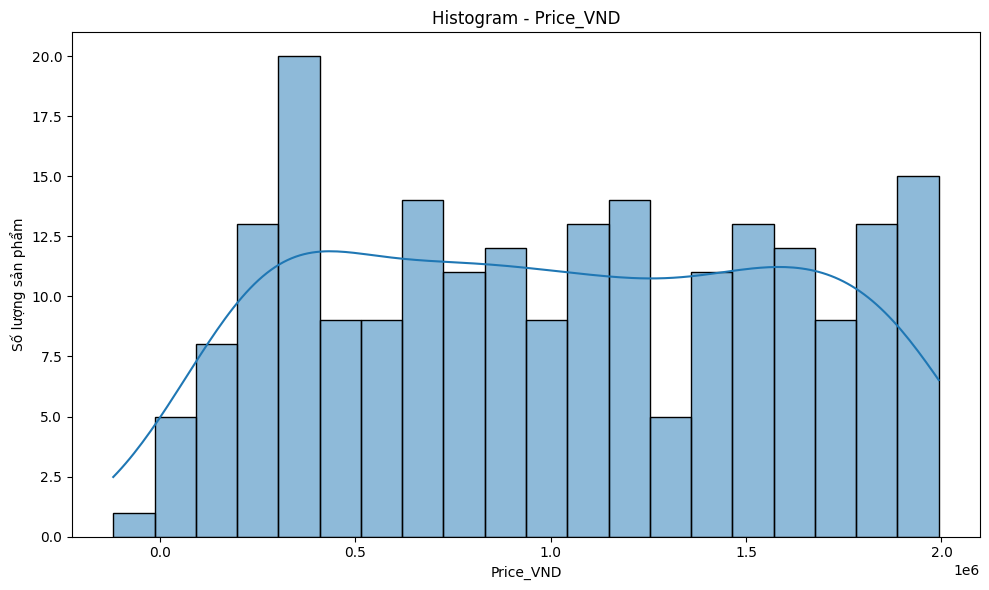

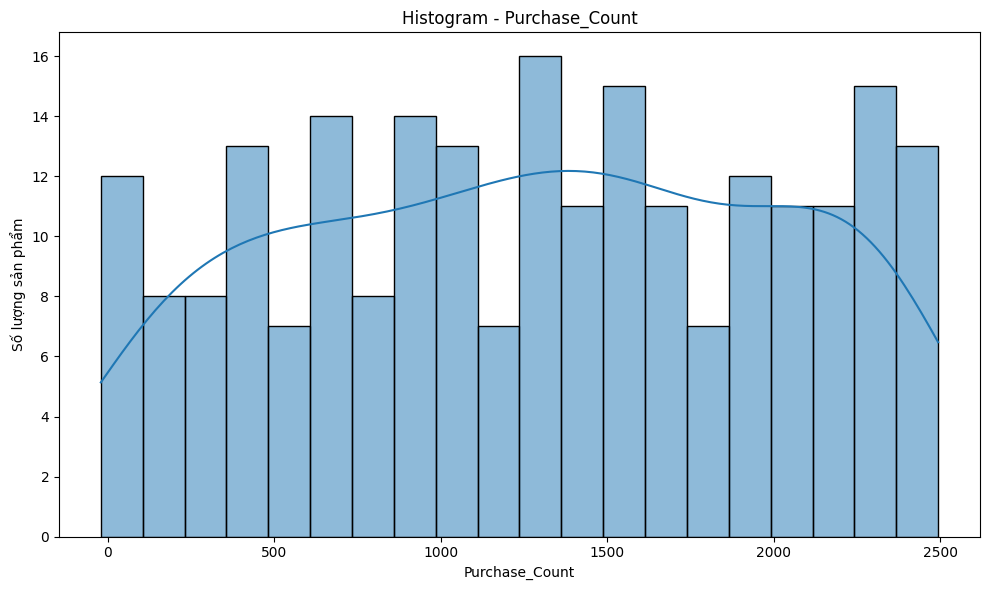

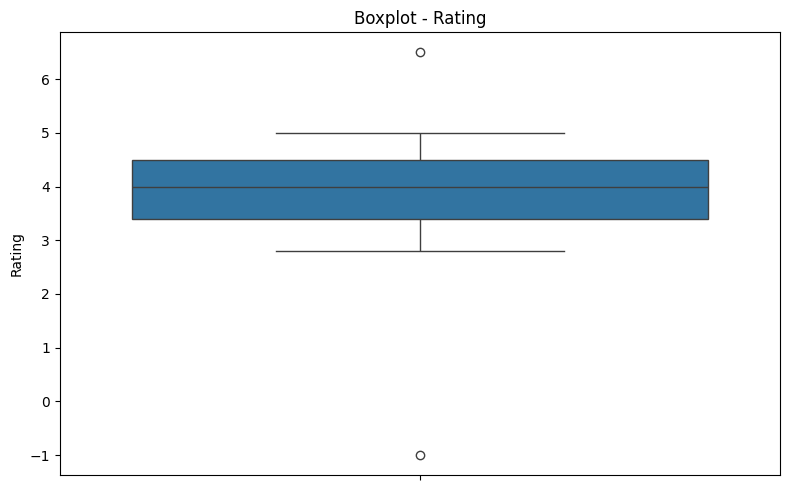

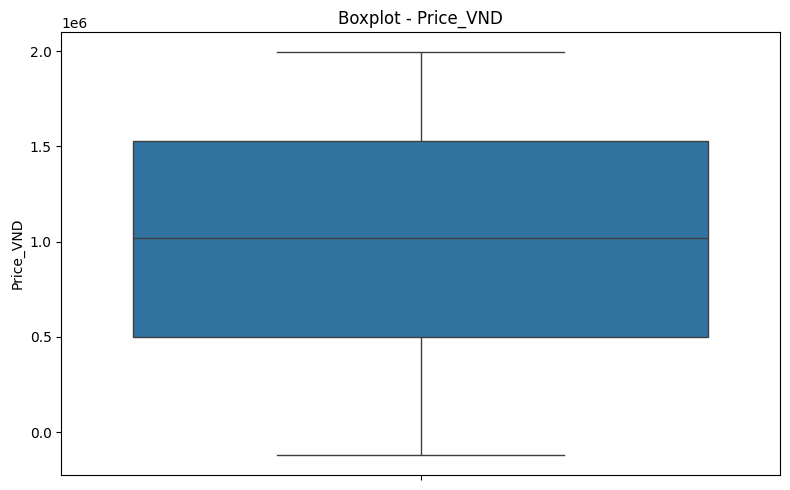

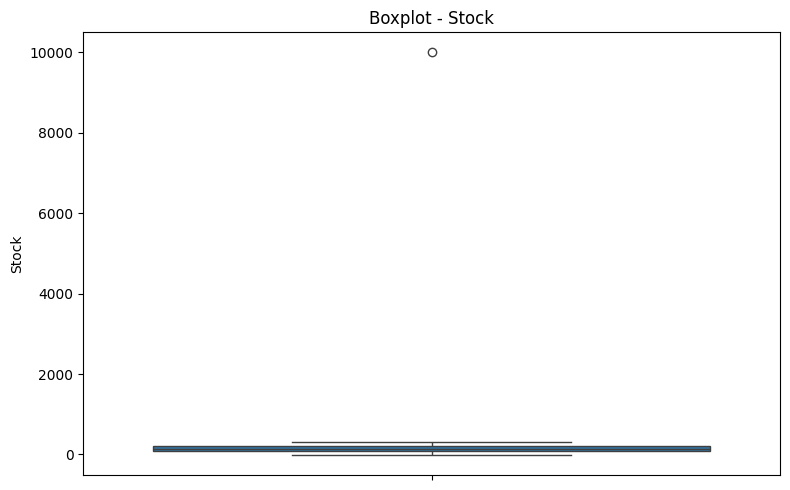

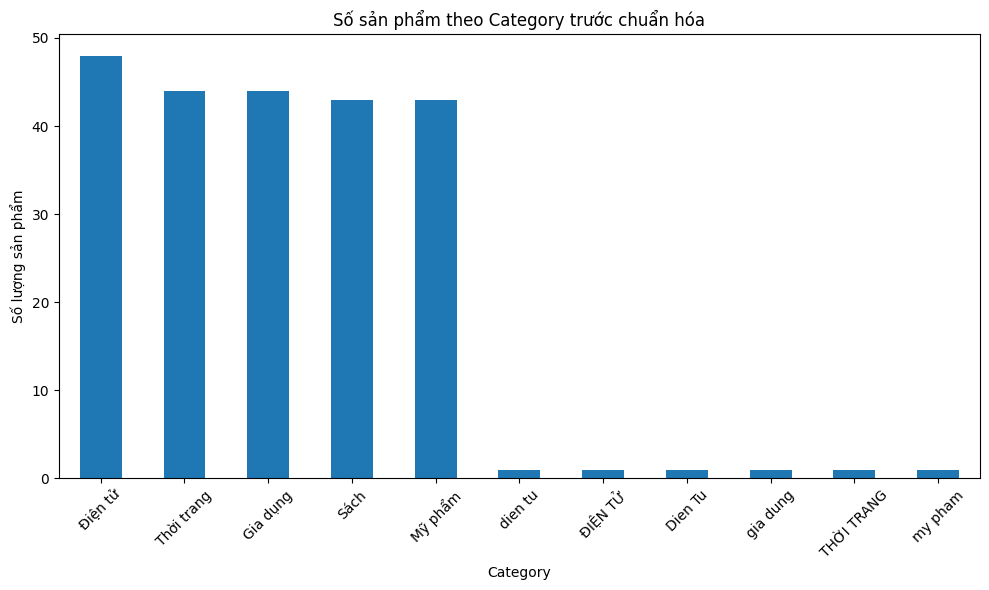


3 NHẬN XÉT

1. Các cột Price_VND, Purchase_Count và một số cột số khác
   có thể chứa dữ liệu dạng chuỗi hoặc ký hiệu nên các giá trị
   không chuyển đổi được sẽ không xuất hiện trong thống kê và
   biểu đồ số ở bước này.

2. Histogram Price_VND và Purchase_Count cho thấy phân phối
   dữ liệu ban đầu. Tuy nhiên, do dữ liệu chưa được chuẩn hóa,
   biểu đồ có thể chưa phản ánh đầy đủ phân phối thực tế.

3. Biểu đồ Category trước chuẩn hóa có thể xuất hiện nhiều nhóm
   có cách viết khác nhau nhưng thực chất thuộc cùng một nhóm.
   Điều này làm số lượng sản phẩm của từng nhóm bị phân tán.



In [10]:
# ============================================================
# BÀI 4: THỐNG KÊ MÔ TẢ VÀ TRỰC QUAN BAN ĐẦU
# ============================================================


# ------------------------------------------------------------
# 1. Các cột số cần thống kê
# ------------------------------------------------------------

stats_columns = [
    "Price_VND",
    "Rating",
    "Purchase_Count",
    "Stock",
    "Weight"
]


# ------------------------------------------------------------
# 2. Tính Count, Mean, Median, Min, Max, Std, Q1, Q3, IQR
# ------------------------------------------------------------

stats = []

for col in stats_columns:

    # Chuyển tạm sang số
    s = pd.to_numeric(
        df[col],
        errors="coerce"
    ).dropna()

    # Q1
    q1 = s.quantile(0.25)

    # Q3
    q3 = s.quantile(0.75)

    # IQR
    iqr = q3 - q1

    stats.append({
        "Cột": col,
        "Count": s.count(),
        "Mean": s.mean(),
        "Median": s.median(),
        "Min": s.min(),
        "Max": s.max(),
        "Std": s.std(),
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr
    })


stats_table = pd.DataFrame(stats)


# Hiển thị kết quả
print("===== THỐNG KÊ MÔ TẢ =====")

display(
    stats_table.round(2)
)


# ============================================================
# 3. Tạo dữ liệu số tạm cho biểu đồ
# ============================================================

price = pd.to_numeric(
    df["Price_VND"],
    errors="coerce"
)

purchase_count = pd.to_numeric(
    df["Purchase_Count"],
    errors="coerce"
)

rating = pd.to_numeric(
    df["Rating"],
    errors="coerce"
)

stock = pd.to_numeric(
    df["Stock"],
    errors="coerce"
)


# ============================================================
# 4. Histogram Price_VND
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    price.dropna(),
    bins=20,
    kde=True
)

plt.title("Histogram - Price_VND")
plt.xlabel("Price_VND")
plt.ylabel("Số lượng sản phẩm")

plt.tight_layout()
plt.show()


# ============================================================
# 5. Histogram Purchase_Count
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    purchase_count.dropna(),
    bins=20,
    kde=True
)

plt.title("Histogram - Purchase_Count")
plt.xlabel("Purchase_Count")
plt.ylabel("Số lượng sản phẩm")

plt.tight_layout()
plt.show()


# ============================================================
# 6. Boxplot Rating
# ============================================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    y=rating.dropna()
)

plt.title("Boxplot - Rating")
plt.ylabel("Rating")

plt.tight_layout()
plt.show()


# ============================================================
# 7. Boxplot Price_VND
# ============================================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    y=price.dropna()
)

plt.title("Boxplot - Price_VND")
plt.ylabel("Price_VND")

plt.tight_layout()
plt.show()


# ============================================================
# 8. Boxplot Stock
# ============================================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    y=stock.dropna()
)

plt.title("Boxplot - Stock")
plt.ylabel("Stock")

plt.tight_layout()
plt.show()


# ============================================================
# 9. Biểu đồ số sản phẩm theo Category
# ============================================================

category_counts = df[
    "Category"
].value_counts(
    dropna=False
)

plt.figure(figsize=(10, 6))

category_counts.plot(
    kind="bar"
)

plt.title(
    "Số sản phẩm theo Category trước chuẩn hóa"
)

plt.xlabel("Category")
plt.ylabel("Số lượng sản phẩm")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# ============================================================
# 10. Ba nhận xét
# ============================================================

print("\n================================================")
print("3 NHẬN XÉT")
print("================================================")

print("""
1. Các cột Price_VND, Purchase_Count và một số cột số khác
   có thể chứa dữ liệu dạng chuỗi hoặc ký hiệu nên các giá trị
   không chuyển đổi được sẽ không xuất hiện trong thống kê và
   biểu đồ số ở bước này.

2. Histogram Price_VND và Purchase_Count cho thấy phân phối
   dữ liệu ban đầu. Tuy nhiên, do dữ liệu chưa được chuẩn hóa,
   biểu đồ có thể chưa phản ánh đầy đủ phân phối thực tế.

3. Biểu đồ Category trước chuẩn hóa có thể xuất hiện nhiều nhóm
   có cách viết khác nhau nhưng thực chất thuộc cùng một nhóm.
   Điều này làm số lượng sản phẩm của từng nhóm bị phân tán.
""")

BÀI 5 — CHUẨN HÓA CHUỖI VÀ BIẾN PHÂN LOẠI

In [11]:
# ============================================================
# BÀI 5: CHUẨN HÓA CHUỖI VÀ BIẾN PHÂN LOẠI
# ============================================================

# Tạo bản dữ liệu sạch từ dữ liệu gốc
df_clean = df_raw.copy()

print("Số dòng ban đầu:", len(df_clean))


# ============================================================
# 1. Loại khoảng trắng thừa ở đầu, cuối và giữa chuỗi
# ============================================================

# Xử lý tất cả các cột có kiểu chuỗi
text_columns = df_clean.select_dtypes(
    include=["object", "string"]
).columns

for col in text_columns:
    df_clean[col] = (
        df_clean[col]
        .astype("string")
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )


# ============================================================
# 2. Chuẩn hóa CATEGORY
# ============================================================

print("\n===== CATEGORY TRƯỚC KHI CHUẨN HÓA =====")
display(df_clean["Category"].value_counts(dropna=False))


def normalize_category(value):

    if pd.isna(value):
        return np.nan

    x = str(value).strip().lower()

    # Loại dấu để nhận diện tiếng Việt
    import unicodedata

    x = unicodedata.normalize(
        "NFD", x
    ).encode(
        "ascii", "ignore"
    ).decode("utf-8")

    x = x.replace(" ", "")
    x = x.replace("-", "")
    x = x.replace("_", "")

    category_mapping = {

        "dientu": "Điện tử",
        "electronics": "Điện tử",

        "thoitrang": "Thời trang",
        "fashion": "Thời trang",

        "giadung": "Gia dụng",
        "home": "Gia dụng",

        "mypham": "Mỹ phẩm",
        "cosmetics": "Mỹ phẩm",

        "thethao": "Thể thao",
        "sports": "Thể thao"
    }

    return category_mapping.get(
        x,
        "Unknown"
    )


df_clean["Category"] = df_clean[
    "Category"
].apply(normalize_category)


# ============================================================
# 3. Chuẩn hóa SELLER_CITY
# ============================================================

print("\n===== SELLER_CITY TRƯỚC KHI CHUẨN HÓA =====")
display(
    df_clean["Seller_City"].value_counts(
        dropna=False
    )
)


def normalize_city(value):

    if pd.isna(value):
        return "Unknown"

    x = str(value).strip().lower()

    import unicodedata

    x = unicodedata.normalize(
        "NFD", x
    ).encode(
        "ascii", "ignore"
    ).decode("utf-8")

    x = x.replace(".", "")
    x = x.replace("-", "")
    x = x.replace(" ", "")

    city_mapping = {

        "hn": "Hà Nội",
        "hanoi": "Hà Nội",

        "hcm": "TP. Hồ Chí Minh",
        "tphcm": "TP. Hồ Chí Minh",
        "hochiminh": "TP. Hồ Chí Minh",
        "saigon": "TP. Hồ Chí Minh",

        "danang": "Đà Nẵng",
        "dn": "Đà Nẵng",

        "haiphong": "Hải Phòng",
        "hp": "Hải Phòng",

        "cantho": "Cần Thơ",
        "ct": "Cần Thơ"
    }

    return city_mapping.get(
        x,
        "Unknown"
    )


df_clean["Seller_City"] = df_clean[
    "Seller_City"
].apply(normalize_city)


# ============================================================
# 4. Chuẩn hóa HAS_IMAGE về 1 và 0
# ============================================================

print("\n===== HAS_IMAGE TRƯỚC KHI CHUẨN HÓA =====")
display(
    df_clean["Has_Image"].value_counts(
        dropna=False
    )
)


def normalize_has_image(value):

    if pd.isna(value):
        return 0

    x = str(value).strip().lower()

    true_values = [
        "1",
        "true",
        "yes",
        "y",
        "co",
        "có",
        "x"
    ]

    false_values = [
        "0",
        "false",
        "no",
        "n",
        "khong",
        "không"
    ]

    if x in true_values:
        return 1

    if x in false_values:
        return 0

    # Giá trị lạ được xem là thiếu
    return 0


df_clean["Has_Image"] = df_clean[
    "Has_Image"
].apply(normalize_has_image).astype("Int64")


# ============================================================
# 5. Kiểm tra lại sau chuẩn hóa
# ============================================================

print("\n===== CATEGORY SAU KHI CHUẨN HÓA =====")
display(
    df_clean["Category"].value_counts(
        dropna=False
    )
)

print("\n===== SELLER_CITY SAU KHI CHUẨN HÓA =====")
display(
    df_clean["Seller_City"].value_counts(
        dropna=False
    )
)

print("\n===== HAS_IMAGE SAU KHI CHUẨN HÓA =====")
display(
    df_clean["Has_Image"].value_counts(
        dropna=False
    )
)


# ============================================================
# 6. Báo cáo số dòng
# ============================================================

print("\n================================================")
print("KẾT QUẢ BÀI 5")
print("================================================")

print("Số dòng trước xử lý:", len(df_raw))
print("Số dòng sau xử lý :", len(df_clean))

print("""
Các cột phân loại/chuỗi đã được chuẩn hóa trên df_clean.
Dữ liệu gốc df_raw không bị thay đổi.
""")

Số dòng ban đầu: 228

===== CATEGORY TRƯỚC KHI CHUẨN HÓA =====


,count
Category,
Điện tử,48
Thời trang,44
Gia dụng,44
Sách,43
Mỹ phẩm,43
dien tu,1
ĐIỆN TỬ,1
Dien Tu,1
gia dung,1



===== SELLER_CITY TRƯỚC KHI CHUẨN HÓA =====


,count
Seller_City,
Hải Phòng,39
TP. Hồ Chí Minh,37
Bắc Ninh,33
Cần Thơ,28
Hà Nội,28
Đà Nẵng,24
Nam Định,24
<NA>,7
HN,2



===== HAS_IMAGE TRƯỚC KHI CHUẨN HÓA =====


...


===== SELLER_CITY SAU KHI CHUẨN HÓA =====


,count
Seller_City,
Unknown,125
Hải Phòng,40
Hà Nội,32
Cần Thơ,28
TP. Hồ Chí Minh,2
Đà Nẵng,1



===== HAS_IMAGE SAU KHI CHUẨN HÓA =====


,count
Has_Image,
1,188
0,40



KẾT QUẢ BÀI 5
Số dòng trước xử lý: 228
Số dòng sau xử lý : 228

Các cột phân loại/chuỗi đã được chuẩn hóa trên df_clean.
Dữ liệu gốc df_raw không bị thay đổi.



BÀI 6 — CHUYỂN ĐỔI KIỂU DỮ LIỆU

In [12]:
# ============================================================
# BÀI 6: CHUYỂN ĐỔI KIỂU DỮ LIỆU
# ============================================================

import re
import unicodedata


# ============================================================
# 1. Hàm chuẩn hóa số cơ bản
# ============================================================

def clean_number_text(value):

    if pd.isna(value):
        return np.nan

    x = str(value).strip()

    if x == "":
        return np.nan

    return x


# ============================================================
# 2. PRICE_VND
# ============================================================

def convert_price(value):

    if pd.isna(value):
        return np.nan

    x = str(value).strip().lower()

    # Trường hợp miễn phí
    if "miễn phí" in x or "mien phi" in x:
        return np.nan

    # Bỏ ký hiệu tiền
    x = x.replace("vnd", "")
    x = x.replace("vnđ", "")
    x = x.replace("đ", "")
    x = x.replace("₫", "")

    x = x.strip()

    if x == "":
        return np.nan

    # Nếu có dấu phẩy và dấu chấm
    if "," in x and "." in x:

        # Ví dụ 1,250,000 -> 1250000
        if x.rfind(",") > x.rfind("."):
            x = x.replace(".", "")
            x = x.replace(",", ".")
        else:
            x = x.replace(",", "")

    elif "," in x:

        # Giá tiền Việt thường dùng dấu phẩy phân cách hàng nghìn
        x = x.replace(",", "")

    elif "." in x:

        # 350.000 -> 350000
        parts = x.split(".")

        if all(part.isdigit() for part in parts):
            if len(parts[-1]) == 3:
                x = "".join(parts)

    try:
        number = float(x)

        # Giá âm được coi là không hợp lệ
        if number < 0:
            return np.nan

        return number

    except:
        return np.nan


df_clean["Price_VND"] = df_clean[
    "Price_VND"
].apply(convert_price)


# ============================================================
# 3. RATING
# ============================================================

def convert_rating(value):

    if pd.isna(value):
        return np.nan

    x = str(value).strip().lower()

    # Lấy phần số
    match = re.search(
        r"\d+(?:[.,]\d+)?",
        x
    )

    if not match:
        return np.nan

    number = match.group().replace(",", ".")

    try:
        return float(number)

    except:
        return np.nan


df_clean["Rating"] = df_clean[
    "Rating"
].apply(convert_rating)


# ============================================================
# 4. PURCHASE_COUNT
# ============================================================

def convert_purchase_count(value):

    if pd.isna(value):
        return np.nan

    x = str(value).strip().lower()

    # Xử lý hậu tố k
    match = re.search(
        r"(\d+(?:[.,]\d+)?)\s*k",
        x
    )

    if match:

        number = float(
            match.group(1).replace(",", ".")
        )

        return number * 1000

    # Trường hợp bình thường
    match = re.search(
        r"\d+(?:[.,]\d+)?",
        x
    )

    if not match:
        return np.nan

    number = match.group().replace(",", ".")

    try:
        return float(number)

    except:
        return np.nan


df_clean["Purchase_Count"] = df_clean[
    "Purchase_Count"
].apply(convert_purchase_count)


# ============================================================
# 5. WEIGHT -> GRAM
# ============================================================

def convert_weight(value):

    if pd.isna(value):
        return np.nan

    x = str(value).strip().lower()

    # Trường hợp "nặng 1kg"
    match = re.search(
        r"(\d+(?:[.,]\d+)?)\s*(kg|g)",
        x
    )

    if not match:
        return np.nan

    number = float(
        match.group(1).replace(",", ".")
    )

    unit = match.group(2)

    if unit == "kg":
        return number * 1000

    return number


df_clean["Weight"] = df_clean[
    "Weight"
].apply(convert_weight)


# ============================================================
# 6. DISCOUNT -> TỶ LỆ 0 - 1
# ============================================================

def convert_discount(value):

    if pd.isna(value):
        return np.nan

    x = str(value).strip()

    if x == "":
        return np.nan

    # Nếu có %
    if "%" in x:

        x = x.replace("%", "").strip()

        try:
            return float(x) / 100

        except:
            return np.nan

    try:

        number = float(
            x.replace(",", ".")
        )

        # Nếu số > 1 thì hiểu là phần trăm
        if number > 1:
            number = number / 100

        return number

    except:
        return np.nan


df_clean["Discount"] = df_clean[
    "Discount"
].apply(convert_discount)


# ============================================================
# 7. CREATED_DATE -> datetime
# ============================================================

df_clean["Created_Date"] = pd.to_datetime(
    df_clean["Created_Date"],
    errors="coerce",
    dayfirst=True
)


# ============================================================
# 8. STOCK -> số
# ============================================================

df_clean["Stock"] = pd.to_numeric(
    df_clean["Stock"],
    errors="coerce"
)


# ============================================================
# 9. HAS_IMAGE -> số nguyên
# ============================================================

df_clean["Has_Image"] = pd.to_numeric(
    df_clean["Has_Image"],
    errors="coerce"
).astype("Int64")


# ============================================================
# 10. Kiểm tra dtype sau chuyển đổi
# ============================================================

print("================================================")
print("KIỂU DỮ LIỆU SAU KHI CHUYỂN ĐỔI")
print("================================================")

df_clean.info()


# ============================================================
# 11. Hiển thị dữ liệu sau chuyển đổi
# ============================================================

print("\n===== 10 DÒNG SAU KHI CHUYỂN ĐỔI =====")

display(
    df_clean.head(10)
)


# ============================================================
# 12. Kiểm tra một số cột quan trọng
# ============================================================

print("\n===== KIỂM TRA CÁC CỘT ĐÃ CHUYỂN ĐỔI =====")

check_columns = [
    "Price_VND",
    "Rating",
    "Purchase_Count",
    "Weight",
    "Discount",
    "Created_Date"
]

display(
    df_clean[check_columns].head(20)
)

KIỂU DỮ LIỆU SAU KHI CHUYỂN ĐỔI
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228 entries, 0 to 227
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Product_ID         228 non-null    string        
 1   Product_Name       228 non-null    string        
 2   Category           228 non-null    object        
 3   Price_VND          217 non-null    float64       
 4   Rating             215 non-null    float64       
 5   Purchase_Count     228 non-null    float64       
 6   Stock              228 non-null    int64         
 7   Seller_City        228 non-null    object        
 8   Created_Date       218 non-null    datetime64[ns]
 9   Weight             3 non-null      float64       
 10  Description        213 non-null    string        
 11  Has_Image          228 non-null    Int64         
 12  Discount           227 non-null    float64       
 13  Target_High_Sales  228 non-null  

/tmp/ipykernel_3463/2057027649.py:263: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df_clean["Created_Date"] = pd.to_datetime(


,Product_ID,Product_Name,Category,Price_VND,Rating,Purchase_Count,Stock,Seller_City,Created_Date,Weight,Description,Has_Image,Discount,Target_High_Sales
0,SP0001,Giày thể thao B2,Thời trang,625000.0,3.2,2290.0,140,Unknown,2026-07-17,NaN,"Giao hàng nhanh, đóng gói cẩn thận",1,0.00,0
1,SP0002,Cơ sở dữ liệu C3,Unknown,377000.0,3.9,1405.0,107,Unknown,2026-05-26,NaN,Chất lượng tốt trong tầm giá,1,0.00,0
2,SP0003,Áo sơ mi D4,Thời trang,1039000.0,3.6,1081.0,87,Unknown,2026-05-06,NaN,<NA>,1,0.25,0
3,SP0004,Khoa học dữ liệu E1,Unknown,824000.0,4.4,323.0,84,Hải Phòng,2026-08-18,NaN,"Thiết kế gọn nhẹ, phù hợp sử dụng hằng ngày",1,0.15,0
4,SP0005,Bàn phím cơ A2,Unknown,NaN,3.9,1655.0,190,Unknown,2026-04-11,NaN,"Giao hàng nhanh, đóng gói cẩn thận",1,0.25,0
5,SP0006,Loa mini B3,Unknown,1878000.0,4.8,775.0,104,Cần Thơ,2026-01-18,NaN,"Thiết kế gọn nhẹ, phù hợp sử dụng hằng ngày",1,0.10,0
6,SP0007,Nồi chiên không dầu C4,Điện tử,1565000.0,3.5,70.0,263,Hải Phòng,2026-08-06,NaN,"Giao hàng nhanh, đóng gói cẩn thận",1,0.15,0
7,SP0008,Máy xay sinh tố D1,Gia dụng,805000.0,4.3,1082.0,142,Unknown,2026-01-22,NaN,"Phiên bản mới, nhiều màu lựa chọn",1,0.10,1
8,SP0009,Máy hút bụi E2,Gia dụng,876000.0,NaN,1650.0,126,Unknown,2026-04-12,NaN,Chất lượng tốt trong tầm giá,1,0.00,1
9,SP0010,Sạc dự phòng A3,Unknown,1414000.0,3.6,119.0,106,Hà Nội,2026-07-11,NaN,"Thiết kế gọn nhẹ, phù hợp sử dụng hằng ngày",1,0.10,0



===== KIỂM TRA CÁC CỘT ĐÃ CHUYỂN ĐỔI =====


,Price_VND,Rating,Purchase_Count,Weight,Discount,Created_Date
0,625000.0,3.2,2290.0,NaN,0.00,2026-07-17
1,377000.0,3.9,1405.0,NaN,0.00,2026-05-26
2,1039000.0,3.6,1081.0,NaN,0.25,2026-05-06
3,824000.0,4.4,323.0,NaN,0.15,2026-08-18
4,NaN,3.9,1655.0,NaN,0.25,2026-04-11
5,1878000.0,4.8,775.0,NaN,0.10,2026-01-18
6,1565000.0,3.5,70.0,NaN,0.15,2026-08-06
7,805000.0,4.3,1082.0,NaN,0.10,2026-01-22
8,876000.0,NaN,1650.0,NaN,0.00,2026-04-12
9,1414000.0,3.6,119.0,NaN,0.10,2026-07-11


BÀI 7 — XỬ LÝ TRÙNG LẶP

In [13]:
# ============================================================
# BÀI 7: XỬ LÝ TRÙNG LẶP
# ============================================================

# ------------------------------------------------------------
# 1. Số dòng trước xử lý
# ------------------------------------------------------------

rows_before = len(df_clean)

print("Số dòng trước xử lý:", rows_before)


# ------------------------------------------------------------
# 2. Đếm dòng trùng hoàn toàn
# ------------------------------------------------------------

exact_duplicates = df_clean.duplicated().sum()

print(
    "Số dòng trùng hoàn toàn:",
    exact_duplicates
)


# ------------------------------------------------------------
# 3. Loại dòng trùng hoàn toàn
# ------------------------------------------------------------

df_clean = df_clean.drop_duplicates().copy()


# ------------------------------------------------------------
# 4. Số dòng sau khi loại trùng hoàn toàn
# ------------------------------------------------------------

rows_after_exact = len(df_clean)

print(
    "Số dòng sau khi loại trùng hoàn toàn:",
    rows_after_exact
)


# ------------------------------------------------------------
# 5. Kiểm tra Product_ID bị trùng
# ------------------------------------------------------------

product_id_count = df_clean[
    "Product_ID"
].value_counts()

duplicate_ids = product_id_count[
    product_id_count > 1
].index


# ------------------------------------------------------------
# 6. Tạo Duplicate_ID_Flag
# ------------------------------------------------------------

df_clean["Duplicate_ID_Flag"] = (
    df_clean["Product_ID"].isin(
        duplicate_ids
    )
)


# ------------------------------------------------------------
# 7. Kiểm tra kết quả
# ------------------------------------------------------------

print("\n===== PRODUCT_ID BỊ TRÙNG =====")

if len(duplicate_ids) > 0:

    print(
        "Số Product_ID còn xung đột:",
        len(duplicate_ids)
    )

    print(
        "Danh sách Product_ID:"
    )

    print(
        duplicate_ids.tolist()
    )

    print("\nCác dòng bị đánh dấu:")

    display(
        df_clean[
            df_clean["Duplicate_ID_Flag"]
        ].sort_values(
            "Product_ID"
        )
    )

else:

    print(
        "Không còn Product_ID bị trùng."
    )


# ------------------------------------------------------------
# 8. Không tự động xóa Product_ID trùng
# ------------------------------------------------------------

print("""
================================================
QUY TẮC XỬ LÝ
================================================

Các dòng trùng hoàn toàn đã được loại bỏ.

Đối với Product_ID trùng nhưng nội dung khác:
- Không xóa tự động.
- Giữ lại dữ liệu.
- Tạo Duplicate_ID_Flag = True để đánh dấu.
- Cần thêm Updated_Time hoặc thông tin phiên bản
  mới có thể xác định bản ghi nào cần giữ.
""")


# ------------------------------------------------------------
# 9. Báo cáo số dòng trước và sau
# ------------------------------------------------------------

print("================================================")
print("BÁO CÁO SỐ DÒNG")
print("================================================")

print("Trước xử lý:", rows_before)
print("Sau loại trùng hoàn toàn:", rows_after_exact)
print(
    "Số dòng đã loại:",
    rows_before - rows_after_exact
)

Số dòng trước xử lý: 228
Số dòng trùng hoàn toàn: 5
Số dòng sau khi loại trùng hoàn toàn: 223

===== PRODUCT_ID BỊ TRÙNG =====
Số Product_ID còn xung đột: 3
Danh sách Product_ID:
['SP0072', 'SP0210', 'SP0180']

Các dòng bị đánh dấu:


,Product_ID,Product_Name,Category,Price_VND,Rating,Purchase_Count,Stock,Seller_City,Created_Date,Weight,Description,Has_Image,Discount,Target_High_Sales,Duplicate_ID_Flag
71,SP0072,Kem chống nắng C1,Mỹ phẩm,1457000.0,4.2,1158.0,98,Cần Thơ,2026-01-01,NaN,"Thiết kế gọn nhẹ, phù hợp sử dụng hằng ngày",1,0.25,1,True
225,SP0072,Bản sao mã sản phẩm,Thời trang,1103000.0,4.9,1098.0,189,Unknown,2026-05-20,NaN,"Giao hàng nhanh, đóng gói cẩn thận",1,0.20,1,True
179,SP0180,Nước tẩy trang A1,Mỹ phẩm,1234000.0,3.6,1936.0,257,Unknown,2026-03-05,NaN,"Giao hàng nhanh, đóng gói cẩn thận",1,0.00,0,True
226,SP0180,Cơ sở dữ liệu B2,Unknown,1234000.0,3.5,1036.0,228,Cần Thơ,2026-06-23,NaN,Chất lượng tốt trong tầm giá,0,0.15,0,True
209,SP0210,Chuột không dây A3,Unknown,1897000.0,4.8,1371.0,164,Unknown,2026-04-15,NaN,"Phiên bản mới, nhiều màu lựa chọn",1,0.25,1,True
227,SP0210,Sạc dự phòng B4,Unknown,1683000.0,3.5,619.0,169,Hà Nội,2026-07-27,NaN,"Phiên bản mới, nhiều màu lựa chọn",1,0.25,0,True



QUY TẮC XỬ LÝ

Các dòng trùng hoàn toàn đã được loại bỏ.

Đối với Product_ID trùng nhưng nội dung khác:
- Không xóa tự động.
- Giữ lại dữ liệu.
- Tạo Duplicate_ID_Flag = True để đánh dấu.
- Cần thêm Updated_Time hoặc thông tin phiên bản
  mới có thể xác định bản ghi nào cần giữ.

BÁO CÁO SỐ DÒNG
Trước xử lý: 228
Sau loại trùng hoàn toàn: 223
Số dòng đã loại: 5


BÀI 8 — XỬ LÝ DỮ LIỆU THIẾU

In [14]:
# ============================================================
# BÀI 8: XỬ LÝ DỮ LIỆU THIẾU
# ============================================================


# ============================================================
# 1. Báo cáo missing SAU KHI chuyển kiểu
# ============================================================

print("===== MISSING REPORT TRƯỚC KHI ĐIỀN =====")

missing_before = pd.DataFrame({
    "Số lượng thiếu": df_clean.isna().sum(),
    "Tỷ lệ thiếu (%)": (
        df_clean.isna().mean() * 100
    )
}).sort_values(
    "Tỷ lệ thiếu (%)",
    ascending=False
)

display(missing_before)


# ============================================================
# 2. PRICE_VND
# Median theo Category
# ============================================================

print("\n===== XỬ LÝ PRICE_VND =====")

price_missing_before = df_clean[
    "Price_VND"
].isna().sum()

print(
    "Price_VND thiếu trước:",
    price_missing_before
)

category_price_median = df_clean.groupby(
    "Category"
)["Price_VND"].transform(
    "median"
)

df_clean["Price_VND"] = df_clean[
    "Price_VND"
].fillna(
    category_price_median
)

# Nếu Category không có median thì dùng median toàn bộ
df_clean["Price_VND"] = df_clean[
    "Price_VND"
].fillna(
    df_clean["Price_VND"].median()
)

print(
    "Price_VND thiếu sau:",
    df_clean["Price_VND"].isna().sum()
)


# ============================================================
# 3. RATING
# Tạo Missing Flag
# ============================================================

print("\n===== XỬ LÝ RATING =====")

df_clean["Rating_Missing_Flag"] = (
    df_clean["Rating"].isna().astype(int)
)

rating_missing_before = df_clean[
    "Rating"
].isna().sum()

print(
    "Rating thiếu trước:",
    rating_missing_before
)

category_rating_median = df_clean.groupby(
    "Category"
)["Rating"].transform(
    "median"
)

df_clean["Rating"] = df_clean[
    "Rating"
].fillna(
    category_rating_median
)

# Fallback median toàn bộ
df_clean["Rating"] = df_clean[
    "Rating"
].fillna(
    df_clean["Rating"].median()
)

print(
    "Rating thiếu sau:",
    df_clean["Rating"].isna().sum()
)


# ============================================================
# 4. SELLER_CITY
# Dùng Unknown cho dữ liệu thiếu
# ============================================================

print("\n===== XỬ LÝ SELLER_CITY =====")

city_missing_before = df_clean[
    "Seller_City"
].isna().sum()

print(
    "Seller_City thiếu trước:",
    city_missing_before
)

df_clean["Seller_City"] = df_clean[
    "Seller_City"
].fillna("Unknown")

print(
    "Seller_City thiếu sau:",
    df_clean["Seller_City"].isna().sum()
)


# ============================================================
# 5. DESCRIPTION
# Dùng "Không có mô tả"
# ============================================================

print("\n===== XỬ LÝ DESCRIPTION =====")

if "Description" in df_clean.columns:

    df_clean["Description_Missing_Flag"] = (
        df_clean["Description"]
        .isna()
        .astype(int)
    )

    description_missing_before = (
        df_clean["Description"]
        .isna()
        .sum()
    )

    print(
        "Description thiếu trước:",
        description_missing_before
    )

    df_clean["Description"] = (
        df_clean["Description"]
        .fillna("Không có mô tả")
    )

    print(
        "Description thiếu sau:",
        df_clean["Description"].isna().sum()
    )


# ============================================================
# 6. CREATED_DATE
# Không bịa ngày
# Giữ NaT
# ============================================================

print("\n===== XỬ LÝ CREATED_DATE =====")

created_date_missing = df_clean[
    "Created_Date"
].isna().sum()

print(
    "Created_Date thiếu/không hợp lệ:",
    created_date_missing
)

print(
    "Các giá trị này được giữ là NaT,"
    " không tự tạo ngày ngẫu nhiên."
)


# ============================================================
# 7. Kiểm tra các cột còn thiếu
# ============================================================

print("\n===== MISSING REPORT SAU XỬ LÝ =====")

missing_after = pd.DataFrame({
    "Số lượng thiếu": df_clean.isna().sum(),
    "Tỷ lệ thiếu (%)": (
        df_clean.isna().mean() * 100
    )
}).sort_values(
    "Tỷ lệ thiếu (%)",
    ascending=False
)

display(missing_after)


# ============================================================
# 8. So sánh trước và sau
# ============================================================

print("\n================================================")
print("SO SÁNH MISSING TRƯỚC - SAU")
print("================================================")

comparison = pd.DataFrame({
    "Trước xử lý": df_raw.isna().sum(),
    "Sau xử lý": df_clean.isna().sum()
})

comparison["Đã giảm"] = (
    comparison["Trước xử lý"]
    - comparison["Sau xử lý"]
)

display(comparison)

===== MISSING REPORT TRƯỚC KHI ĐIỀN =====


,Số lượng thiếu,Tỷ lệ thiếu (%)
Weight,220,98.654709
Description,15,6.726457
Rating,13,5.829596
Price_VND,11,4.932735
Created_Date,10,4.484305
Discount,1,0.448430
Product_ID,0,0.000000
Stock,0,0.000000
Purchase_Count,0,0.000000
Product_Name,0,0.000000



===== XỬ LÝ PRICE_VND =====
Price_VND thiếu trước: 11
Price_VND thiếu sau: 0

===== XỬ LÝ RATING =====
Rating thiếu trước: 13
Rating thiếu sau: 0

===== XỬ LÝ SELLER_CITY =====
Seller_City thiếu trước: 0
Seller_City thiếu sau: 0

===== XỬ LÝ DESCRIPTION =====
Description thiếu trước: 15
Description thiếu sau: 0

===== XỬ LÝ CREATED_DATE =====
Created_Date thiếu/không hợp lệ: 10
Các giá trị này được giữ là NaT, không tự tạo ngày ngẫu nhiên.

===== MISSING REPORT SAU XỬ LÝ =====


,Số lượng thiếu,Tỷ lệ thiếu (%)
Weight,220,98.654709
Created_Date,10,4.484305
Discount,1,0.448430
Product_ID,0,0.000000
Product_Name,0,0.000000
Rating,0,0.000000
Purchase_Count,0,0.000000
Price_VND,0,0.000000
Category,0,0.000000
Seller_City,0,0.000000



SO SÁNH MISSING TRƯỚC - SAU


,Trước xử lý,Sau xử lý,Đã giảm
Category,0.0,0,0.0
Created_Date,6.0,10,-4.0
Description,15.0,0,15.0
Description_Missing_Flag,NaN,0,NaN
Discount,0.0,1,-1.0
Duplicate_ID_Flag,NaN,0,NaN
Has_Image,0.0,0,0.0
Price_VND,9.0,0,9.0
Product_ID,0.0,0,0.0
Product_Name,0.0,0,0.0


BÀI 9 — XỬ LÝ NGOẠI LỆ VÀ GIÁ TRỊ NGOÀI MIỀN

In [15]:
# ============================================================
# BÀI 9: XỬ LÝ NGOẠI LỆ VÀ GIÁ TRỊ NGOÀI MIỀN
# ============================================================


# ============================================================
# 1. Rating ngoài [1, 5]
# ============================================================

print("===== RATING NGOÀI [1, 5] =====")

rating_invalid = (
    df_clean["Rating"].notna()
    & ~df_clean["Rating"].between(1, 5)
)

print(
    "Số Rating không hợp lệ:",
    rating_invalid.sum()
)

if rating_invalid.sum() > 0:

    display(
        df_clean.loc[
            rating_invalid,
            ["Product_ID", "Rating"]
        ]
    )

# Đưa Rating lỗi thành NaN
df_clean.loc[
    rating_invalid,
    "Rating"
] = np.nan


# ============================================================
# 2. Price_VND <= 0
# ============================================================

print("\n===== PRICE_VND <= 0 =====")

price_invalid = (
    df_clean["Price_VND"].notna()
    & (df_clean["Price_VND"] <= 0)
)

print(
    "Số Price_VND không hợp lệ:",
    price_invalid.sum()
)

if price_invalid.sum() > 0:

    display(
        df_clean.loc[
            price_invalid,
            ["Product_ID", "Price_VND"]
        ]
    )

# Đưa giá không hợp lệ thành NaN
df_clean.loc[
    price_invalid,
    "Price_VND"
] = np.nan


# ============================================================
# 3. Purchase_Count âm
# ============================================================

print("\n===== PURCHASE_COUNT ÂM =====")

purchase_invalid = (
    df_clean["Purchase_Count"].notna()
    & (df_clean["Purchase_Count"] < 0)
)

print(
    "Số Purchase_Count âm:",
    purchase_invalid.sum()
)

if purchase_invalid.sum() > 0:

    display(
        df_clean.loc[
            purchase_invalid,
            ["Product_ID", "Purchase_Count"]
        ]
    )

df_clean.loc[
    purchase_invalid,
    "Purchase_Count"
] = np.nan


# ============================================================
# 4. Stock âm
# ============================================================

print("\n===== STOCK ÂM =====")

stock_invalid = (
    df_clean["Stock"].notna()
    & (df_clean["Stock"] < 0)
)

print(
    "Số Stock âm:",
    stock_invalid.sum()
)

if stock_invalid.sum() > 0:

    display(
        df_clean.loc[
            stock_invalid,
            ["Product_ID", "Stock"]
        ]
    )

df_clean.loc[
    stock_invalid,
    "Stock"
] = np.nan


# ============================================================
# 5. Discount ngoài [0, 1]
# ============================================================

print("\n===== DISCOUNT NGOÀI [0, 1] =====")

discount_invalid = (
    df_clean["Discount"].notna()
    & ~df_clean["Discount"].between(0, 1)
)

print(
    "Số Discount không hợp lệ:",
    discount_invalid.sum()
)

if discount_invalid.sum() > 0:

    display(
        df_clean.loc[
            discount_invalid,
            ["Product_ID", "Discount"]
        ]
    )

df_clean.loc[
    discount_invalid,
    "Discount"
] = np.nan


# ============================================================
# 6. Kiểm tra Stock bằng IQR
# ============================================================

print("\n===== PHÁT HIỆN NGOẠI LỆ STOCK BẰNG IQR =====")

stock_valid = df_clean[
    "Stock"
].dropna()

if len(stock_valid) > 0:

    Q1 = stock_valid.quantile(0.25)
    Q3 = stock_valid.quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    stock_outlier = (
        df_clean["Stock"].notna()
        & (
            (df_clean["Stock"] < lower_bound)
            |
            (df_clean["Stock"] > upper_bound)
        )
    )

    print("Q1 =", Q1)
    print("Q3 =", Q3)
    print("IQR =", IQR)
    print("Ngưỡng dưới =", lower_bound)
    print("Ngưỡng trên =", upper_bound)

    print(
        "Số Stock bị gắn cờ:",
        stock_outlier.sum()
    )

    if stock_outlier.sum() > 0:

        display(
            df_clean.loc[
                stock_outlier,
                ["Product_ID", "Stock"]
            ].sort_values(
                "Stock",
                ascending=False
            )
        )

    # Chỉ gắn cờ, KHÔNG tự động xóa
    df_clean["Stock_Outlier_Flag"] = (
        stock_outlier.astype(int)
    )


# ============================================================
# 7. Kiểm tra Purchase_Count bằng IQR
# ============================================================

purchase_valid = df_clean[
    "Purchase_Count"
].dropna()

if len(purchase_valid) > 0:

    Q1_purchase = purchase_valid.quantile(0.25)
    Q3_purchase = purchase_valid.quantile(0.75)

    IQR_purchase = (
        Q3_purchase - Q1_purchase
    )

    lower_purchase = (
        Q1_purchase - 1.5 * IQR_purchase
    )

    upper_purchase = (
        Q3_purchase + 1.5 * IQR_purchase
    )

    purchase_outlier = (
        df_clean["Purchase_Count"].notna()
        &
        (
            (df_clean["Purchase_Count"] < lower_purchase)
            |
            (df_clean["Purchase_Count"] > upper_purchase)
        )
    )

    df_clean["Purchase_Outlier_Flag"] = (
        purchase_outlier.astype(int)
    )

    print("\n===== PURCHASE_COUNT OUTLIER =====")

    print(
        "Số giá trị bị gắn cờ:",
        purchase_outlier.sum()
    )


# ============================================================
# 8. Kiểm tra lại miền giá trị sau xử lý
# ============================================================

print("\n================================================")
print("KIỂM TRA CUỐI BÀI 9")
print("================================================")


print("\nRating ngoài [1,5]:",
      (
          df_clean["Rating"].notna()
          & ~df_clean["Rating"].between(1,5)
      ).sum()
)


print("Price_VND <= 0:",
      (
          df_clean["Price_VND"].notna()
          & (df_clean["Price_VND"] <= 0)
      ).sum()
)


print("Purchase_Count âm:",
      (
          df_clean["Purchase_Count"].notna()
          & (df_clean["Purchase_Count"] < 0)
      ).sum()
)


print("Stock âm:",
      (
          df_clean["Stock"].notna()
          & (df_clean["Stock"] < 0)
      ).sum()
)


print("Discount ngoài [0,1]:",
      (
          df_clean["Discount"].notna()
          & ~df_clean["Discount"].between(0,1)
      ).sum()
)


# ============================================================
# 9. Dtype cuối Tiết 2
# ============================================================

print("\n===== DTYPE CUỐI TIẾT 2 =====")

df_clean.info()


# ============================================================
# 10. Số dòng cuối cùng
# ============================================================

print("\n===== SỐ DÒNG =====")

print(
    "Số dòng df_raw:",
    len(df_raw)
)

print(
    "Số dòng df_clean:",
    len(df_clean)
)


# ============================================================
# KẾT LUẬN
# ============================================================

print("""
================================================
KẾT LUẬN BÀI 9
================================================

- Các giá trị chắc chắn không hợp lệ đã được đưa về NaN.
- Không tự động lấy trị tuyệt đối cho Stock/Purchase_Count âm.
- Stock ngoại lệ được phát hiện bằng IQR và gắn cờ.
- Các ngoại lệ hiếm không bị tự động xóa nếu chưa có căn cứ.
- df_raw vẫn được giữ nguyên để so sánh trước và sau.
""")

===== RATING NGOÀI [1, 5] =====
Số Rating không hợp lệ: 1


,Product_ID,Rating
74,SP0075,6.5



===== PRICE_VND <= 0 =====
Số Price_VND không hợp lệ: 0

===== PURCHASE_COUNT ÂM =====
Số Purchase_Count âm: 0

===== STOCK ÂM =====
Số Stock âm: 1


,Product_ID,Stock
39,SP0040,-15



===== DISCOUNT NGOÀI [0, 1] =====
Số Discount không hợp lệ: 1


,Product_ID,Discount
194,SP0195,-0.1



===== PHÁT HIỆN NGOẠI LỆ STOCK BẰNG IQR =====
Q1 = 94.0
Q3 = 219.25
IQR = 125.25
Ngưỡng dưới = -93.875
Ngưỡng trên = 407.125
Số Stock bị gắn cờ: 1


,Product_ID,Stock
128,SP0129,9999.0



===== PURCHASE_COUNT OUTLIER =====
Số giá trị bị gắn cờ: 0

KIỂM TRA CUỐI BÀI 9

Rating ngoài [1,5]: 0
Price_VND <= 0: 0
Purchase_Count âm: 0
Stock âm: 0
Discount ngoài [0,1]: 0

===== DTYPE CUỐI TIẾT 2 =====
<class 'pandas.core.frame.DataFrame'>
Index: 223 entries, 0 to 227
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Product_ID                223 non-null    string        
 1   Product_Name              223 non-null    string        
 2   Category                  223 non-null    object        
 3   Price_VND                 223 non-null    float64       
 4   Rating                    222 non-null    float64       
 5   Purchase_Count            223 non-null    float64       
 6   Stock                     222 non-null    float64       
 7   Seller_City               223 non-null    object        
 8   Created_Date              213 non-null    datetime64[ns]
 9   Wei

BÀI 10 — TẠO ĐẶC TRƯNG MỚI

In [16]:
# ============================================================
# BÀI 10: TẠO ĐẶC TRƯNG MỚI
# ============================================================

import pandas as pd
import numpy as np

print("================================================")
print("BÀI 10 - TẠO ĐẶC TRƯNG MỚI")
print("================================================")

# Kiểm tra số dòng trước khi tạo đặc trưng
rows_before = len(df_clean)

print("Số dòng trước khi tạo đặc trưng:", rows_before)


# ============================================================
# 1. Product_Age_Days
# ============================================================
# Ngày tham chiếu theo đề: 01/09/2026

reference_date = pd.Timestamp("2026-09-01")

df_clean["Product_Age_Days"] = (
    reference_date - df_clean["Created_Date"]
).dt.days

print("\n===== Product_Age_Days =====")

display(
    df_clean[
        [
            "Product_ID",
            "Created_Date",
            "Product_Age_Days"
        ]
    ].head(10)
)


# ============================================================
# 2. Discounted_Price
# ============================================================
# Công thức:
# Discounted_Price = Price_VND * (1 - Discount)

df_clean["Discounted_Price"] = (
    df_clean["Price_VND"]
    * (1 - df_clean["Discount"])
)

print("\n===== Discounted_Price =====")

display(
    df_clean[
        [
            "Product_ID",
            "Price_VND",
            "Discount",
            "Discounted_Price"
        ]
    ].head(10)
)


# ============================================================
# 3. Estimated_Revenue
# ============================================================
# Công thức:
# Estimated_Revenue =
# Discounted_Price * Purchase_Count

df_clean["Estimated_Revenue"] = (
    df_clean["Discounted_Price"]
    * df_clean["Purchase_Count"]
)

print("\n===== Estimated_Revenue =====")

display(
    df_clean[
        [
            "Product_ID",
            "Discounted_Price",
            "Purchase_Count",
            "Estimated_Revenue"
        ]
    ].head(10)
)


# ============================================================
# 4. Description_Length
# ============================================================
# Đếm số ký tự trong Description

if "Description" in df_clean.columns:

    df_clean["Description_Length"] = (
        df_clean["Description"]
        .fillna("")
        .astype(str)
        .str.len()
    )

else:

    print("Không tìm thấy cột Description.")


print("\n===== Description_Length =====")

if "Description_Length" in df_clean.columns:

    display(
        df_clean[
            [
                "Product_ID",
                "Description",
                "Description_Length"
            ]
        ].head(10)
    )


# ============================================================
# 5. Kiểm tra Target_High_Sales
# ============================================================

print("\n===== KIỂM TRA TARGET =====")

if "Target_High_Sales" in df_clean.columns:

    print(
        "Target_High_Sales tồn tại và KHÔNG được sử dụng "
        "để tạo các đặc trưng mới."
    )

else:

    print(
        "Không tìm thấy Target_High_Sales trong dữ liệu."
    )


# ============================================================
# 6. Danh sách các cột mới
# ============================================================

new_features = [
    "Product_Age_Days",
    "Discounted_Price",
    "Estimated_Revenue",
    "Description_Length"
]

print("\n===== CÁC ĐẶC TRƯNG MỚI =====")

for col in new_features:

    if col in df_clean.columns:

        print(
            f"{col}: {df_clean[col].dtype}"
        )


# ============================================================
# 7. Kiểm tra missing của các đặc trưng mới
# ============================================================

print("\n===== MISSING CỦA ĐẶC TRƯNG MỚI =====")

display(
    df_clean[new_features]
    .isna()
    .sum()
    .to_frame("Số lượng thiếu")
)


# ============================================================
# 8. Hiển thị dữ liệu sau khi tạo đặc trưng
# ============================================================

print("\n===== 10 DÒNG SAU KHI TẠO ĐẶC TRƯNG =====")

display(
    df_clean[
        [
            "Product_ID",
            "Product_Age_Days",
            "Price_VND",
            "Discount",
            "Discounted_Price",
            "Purchase_Count",
            "Estimated_Revenue",
            "Description_Length"
        ]
    ].head(10)
)


# ============================================================
# 9. Kiểm tra số dòng
# ============================================================

rows_after = len(df_clean)

print("\n================================================")
print("KẾT QUẢ BÀI 10")
print("================================================")

print("Số dòng trước:", rows_before)
print("Số dòng sau  :", rows_after)

print(
    "Số dòng thay đổi:",
    rows_after - rows_before
)

print("\nĐã tạo:")
print("- Product_Age_Days")
print("- Discounted_Price")
print("- Estimated_Revenue")
print("- Description_Length")

print(
    "\nTarget_High_Sales không được sử dụng "
    "để tạo đặc trưng."
)

BÀI 10 - TẠO ĐẶC TRƯNG MỚI
Số dòng trước khi tạo đặc trưng: 223

===== Product_Age_Days =====


,Product_ID,Created_Date,Product_Age_Days
0,SP0001,2026-07-17,46.0
1,SP0002,2026-05-26,98.0
2,SP0003,2026-05-06,118.0
3,SP0004,2026-08-18,14.0
4,SP0005,2026-04-11,143.0
5,SP0006,2026-01-18,226.0
6,SP0007,2026-08-06,26.0
7,SP0008,2026-01-22,222.0
8,SP0009,2026-04-12,142.0
9,SP0010,2026-07-11,52.0



===== Discounted_Price =====


,Product_ID,Price_VND,Discount,Discounted_Price
0,SP0001,625000.0,0.00,625000.0
1,SP0002,377000.0,0.00,377000.0
2,SP0003,1039000.0,0.25,779250.0
3,SP0004,824000.0,0.15,700400.0
4,SP0005,1339000.0,0.25,1004250.0
5,SP0006,1878000.0,0.10,1690200.0
6,SP0007,1565000.0,0.15,1330250.0
7,SP0008,805000.0,0.10,724500.0
8,SP0009,876000.0,0.00,876000.0
9,SP0010,1414000.0,0.10,1272600.0



===== Estimated_Revenue =====


...


===== KIỂM TRA TARGET =====
Target_High_Sales tồn tại và KHÔNG được sử dụng để tạo các đặc trưng mới.

===== CÁC ĐẶC TRƯNG MỚI =====
Product_Age_Days: float64
Discounted_Price: float64
Estimated_Revenue: float64
Description_Length: int64

===== MISSING CỦA ĐẶC TRƯNG MỚI =====


,Số lượng thiếu
Product_Age_Days,10
Discounted_Price,2
Estimated_Revenue,2
Description_Length,0



===== 10 DÒNG SAU KHI TẠO ĐẶC TRƯNG =====


,Product_ID,Product_Age_Days,Price_VND,Discount,Discounted_Price,Purchase_Count,Estimated_Revenue,Description_Length
0,SP0001,46.0,625000.0,0.00,625000.0,2290.0,1.431250e+09,34
1,SP0002,98.0,377000.0,0.00,377000.0,1405.0,5.296850e+08,28
2,SP0003,118.0,1039000.0,0.25,779250.0,1081.0,8.423692e+08,14
3,SP0004,14.0,824000.0,0.15,700400.0,323.0,2.262292e+08,43
4,SP0005,143.0,1339000.0,0.25,1004250.0,1655.0,1.662034e+09,34
5,SP0006,226.0,1878000.0,0.10,1690200.0,775.0,1.309905e+09,43
6,SP0007,26.0,1565000.0,0.15,1330250.0,70.0,9.311750e+07,34
7,SP0008,222.0,805000.0,0.10,724500.0,1082.0,7.839090e+08,33
8,SP0009,142.0,876000.0,0.00,876000.0,1650.0,1.445400e+09,28
9,SP0010,52.0,1414000.0,0.10,1272600.0,119.0,1.514394e+08,43



KẾT QUẢ BÀI 10
Số dòng trước: 223
Số dòng sau  : 223
Số dòng thay đổi: 0

Đã tạo:
- Product_Age_Days
- Discounted_Price
- Estimated_Revenue
- Description_Length

Target_High_Sales không được sử dụng để tạo đặc trưng.


In [ ]:
BÀI 11 — PHÂN PHỐI VÀ BIẾN ĐỔI THANG ĐO

BÀI 11 - PHÂN PHỐI VÀ BIẾN ĐỔI THANG ĐO

===== SKEWNESS TRƯỚC LOG TRANSFORM =====


,Biến,Skewness
0,Price_VND,-0.0046
1,Purchase_Count,-0.0647
2,Estimated_Revenue,1.0761



===== NHẬN XÉT SKEWNESS =====
Price_VND: skewness = -0.0046 → Tương đối cân bằng
Purchase_Count: skewness = -0.0647 → Tương đối cân bằng
Estimated_Revenue: skewness = 1.0761 → Lệch phải mạnh

===== SKEWNESS SAU LOG1P =====


,Biến,Skewness trước,Skewness sau log1p,Mức thay đổi
0,Price_VND,-0.0046,-1.1834,-1.1787
1,Purchase_Count,-0.0647,-2.5114,-2.4467
2,Estimated_Revenue,1.0761,-6.0142,-7.0903


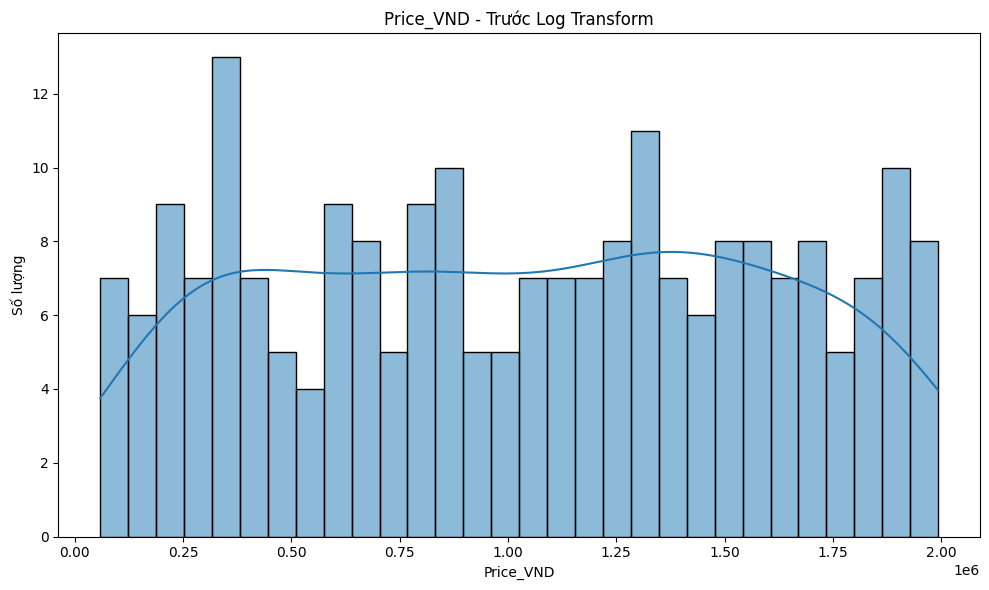

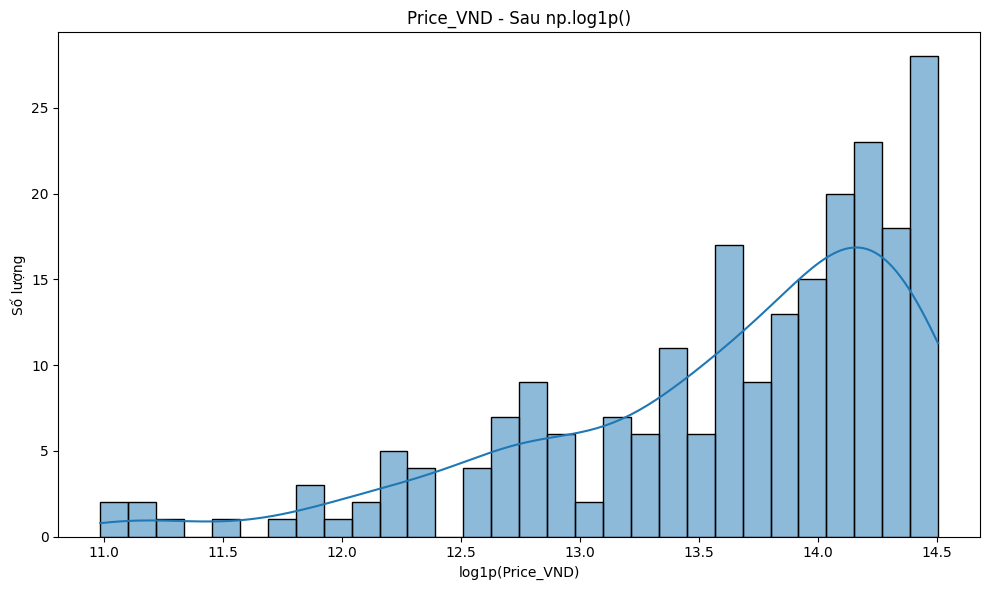

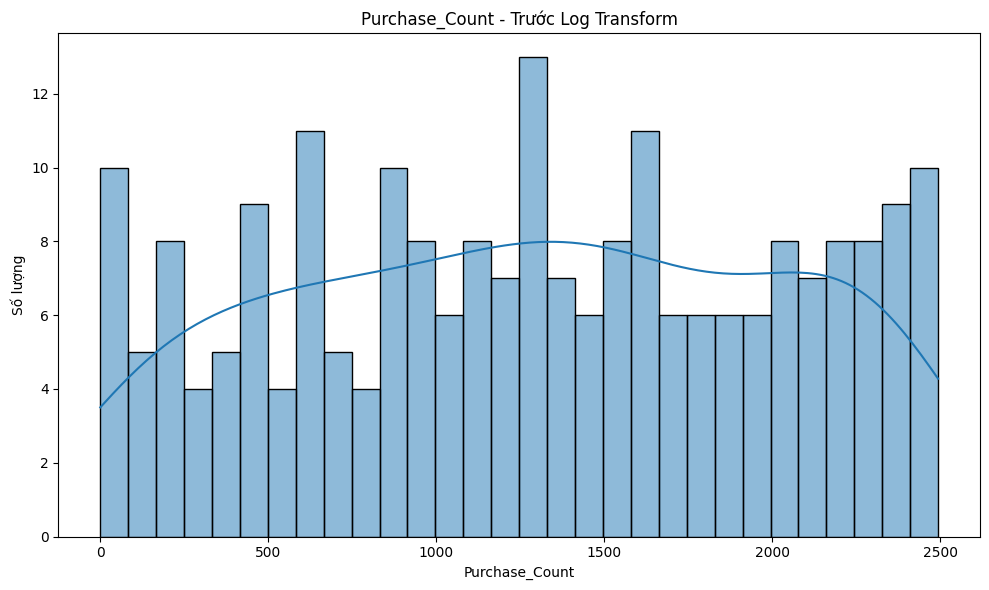

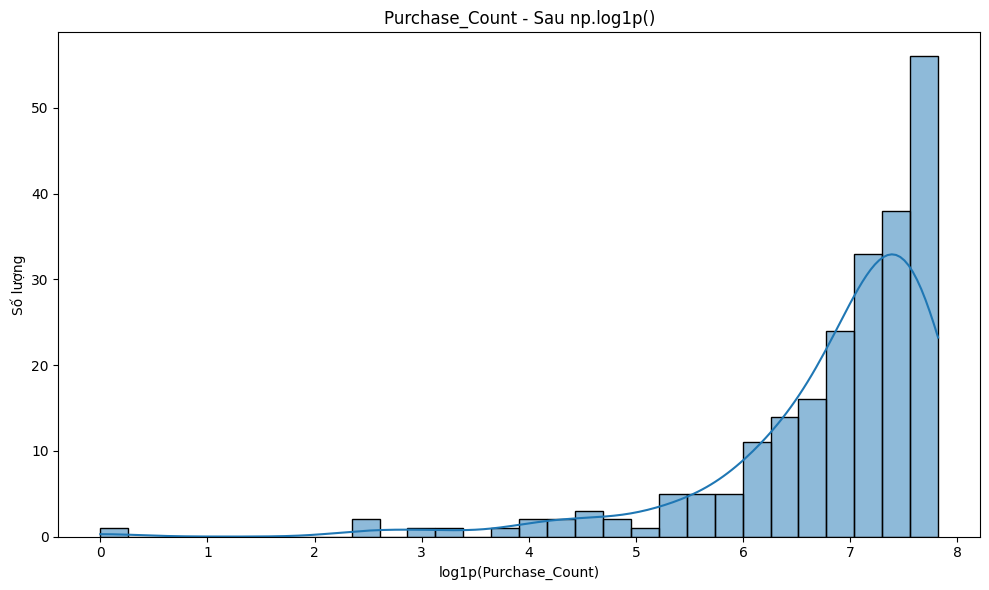

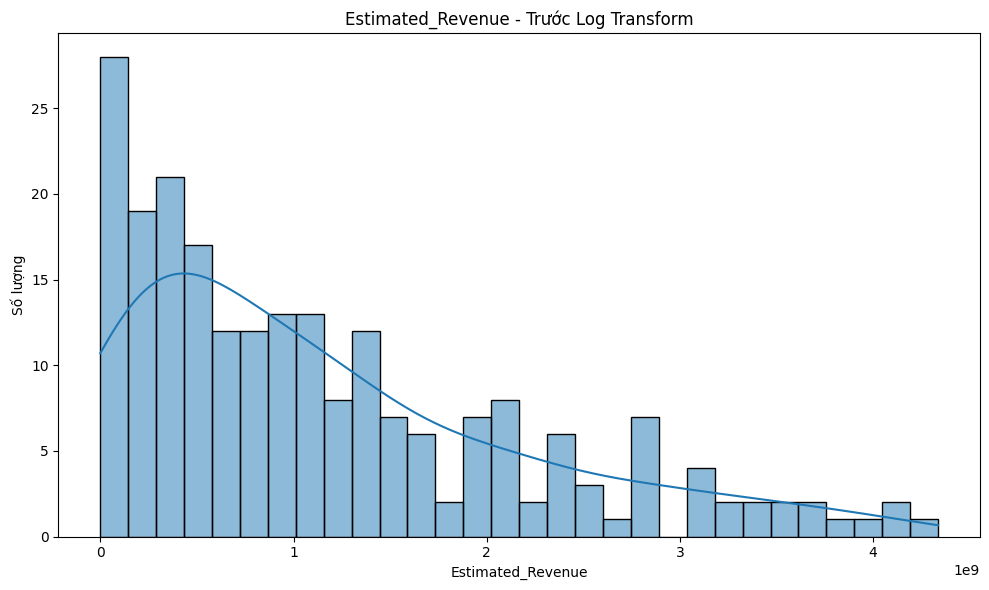

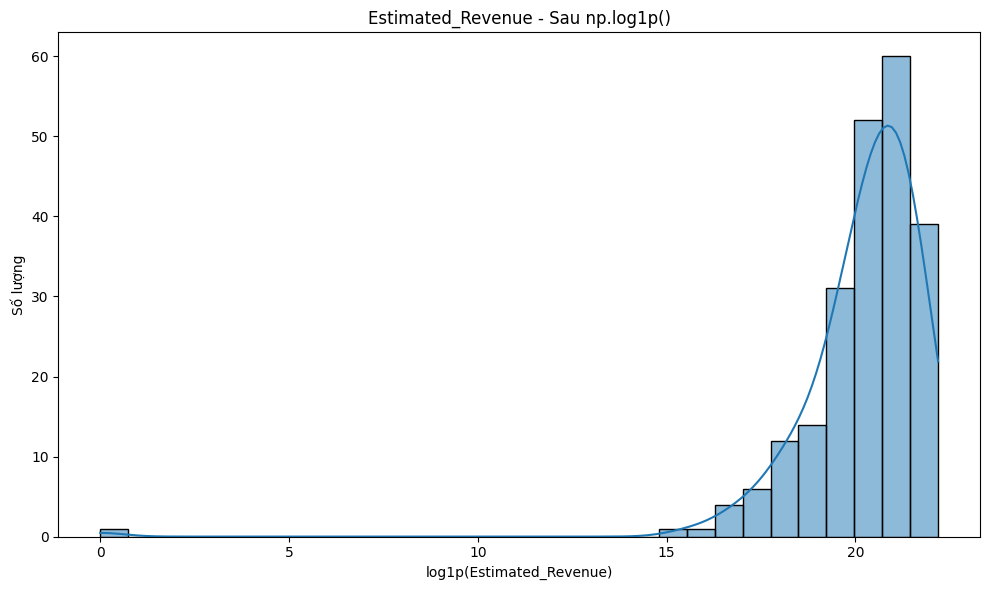


===== KÍCH THƯỚC DỮ LIỆU DÙNG CHO SCALER =====
Số dòng: 221
Số cột: 3

===== STANDARD SCALER =====


,Price_VND,Purchase_Count,Estimated_Revenue
count,221.000,221.000,221.000
mean,-0.000,0.000,-0.000
std,1.002,1.002,1.002
min,-1.717,-1.780,-1.131
25%,-0.888,-0.843,-0.777
50%,0.023,0.028,-0.244
75%,0.838,0.856,0.468
max,1.716,1.667,3.106



===== ROBUST SCALER =====


,Price_VND,Purchase_Count,Estimated_Revenue
count,221.000,221.000,221.000
mean,-0.013,-0.016,0.196
std,0.581,0.590,0.806
min,-1.008,-1.064,-0.713
25%,-0.528,-0.513,-0.428
50%,0.000,0.000,0.000
75%,0.472,0.487,0.572
max,0.981,0.965,2.692



===== SO SÁNH 10 DÒNG ĐẦU =====


,Price_VND_Standard,Price_VND_Robust,Purchase_Count_Standard,Purchase_Count_Robust,Estimated_Revenue_Standard,Estimated_Revenue_Robust
0,-0.712,-0.426,1.385,0.799,0.267,0.411
1,-1.153,-0.681,0.162,0.079,-0.614,-0.297
2,0.023,0.000,-0.286,-0.185,-0.308,-0.051
3,-0.359,-0.221,-1.333,-0.801,-0.910,-0.535
4,0.555,0.309,0.508,0.282,0.493,0.592
5,1.512,0.863,-0.709,-0.434,0.149,0.316
6,0.957,0.541,-1.683,-1.007,-1.040,-0.640
7,-0.393,-0.241,-0.284,-0.184,-0.365,-0.097
8,-0.267,-0.168,0.501,0.278,0.281,0.422
9,0.688,0.386,-1.615,-0.967,-0.983,-0.594



KẾT LUẬN LOG TRANSFORM

np.log1p(x) hữu ích khi biến số có phân phối lệch phải mạnh,
đặc biệt khi có một số giá trị rất lớn.

Log transform có thể:
- Giảm mức độ lệch phải.
- Thu hẹp khoảng cách giữa các giá trị rất lớn và nhỏ.
- Giúp dữ liệu dễ xử lý hơn trong một số mô hình.

Không nên dùng log1p trực tiếp cho giá trị âm.

Với dữ liệu có giá trị âm, cần xử lý theo quy tắc phù hợp
trước khi log transform.


KẾT LUẬN SCALER

StandardScaler:
- Chuẩn hóa dựa trên mean và standard deviation.
- Nhạy với outlier.

RobustScaler:
- Sử dụng median và IQR.
- Ít bị ảnh hưởng bởi outlier hơn.

Nếu dữ liệu có các giá trị ngoại lệ rất lớn như Stock = 9999,
RobustScaler thường phù hợp hơn khi muốn giảm ảnh hưởng
của các giá trị cực đoan.

Tuy nhiên, việc chọn scaler cuối cùng phụ thuộc vào mô hình
và mục tiêu phân tích.


NGUYÊN TẮC CHỐNG RÒ RỈ DỮ LIỆU

Trong dự án mô hình hóa thực tế:

1. Chia dữ liệu thành train/test trước.

2. Chỉ fit imputer trên tập train.

3. Chỉ fit scaler trên tập train.

4

In [17]:
# ============================================================
# BÀI 11: PHÂN PHỐI VÀ BIẾN ĐỔI THANG ĐO
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, RobustScaler


print("================================================")
print("BÀI 11 - PHÂN PHỐI VÀ BIẾN ĐỔI THANG ĐO")
print("================================================")


# ============================================================
# 1. Các biến cần phân tích
# ============================================================

analysis_columns = [
    "Price_VND",
    "Purchase_Count",
    "Estimated_Revenue"
]


# ============================================================
# 2. Tính skewness
# ============================================================

print("\n===== SKEWNESS TRƯỚC LOG TRANSFORM =====")

skewness_before = {}

for col in analysis_columns:

    values = pd.to_numeric(
        df_clean[col],
        errors="coerce"
    ).dropna()

    skewness_before[col] = values.skew()


skewness_table = pd.DataFrame({
    "Biến": analysis_columns,
    "Skewness": [
        skewness_before[col]
        for col in analysis_columns
    ]
})


display(
    skewness_table.round(4)
)


# ============================================================
# 3. Giải thích mức độ lệch
# ============================================================

print("\n===== NHẬN XÉT SKEWNESS =====")

for col in analysis_columns:

    value = skewness_before[col]

    if value > 1:

        comment = "Lệch phải mạnh"

    elif value > 0.5:

        comment = "Lệch phải"

    elif value < -1:

        comment = "Lệch trái mạnh"

    elif value < -0.5:

        comment = "Lệch trái"

    else:

        comment = "Tương đối cân bằng"

    print(
        f"{col}: skewness = {value:.4f} → {comment}"
    )


# ============================================================
# 4. Tạo dữ liệu log1p
# ============================================================
# log1p(x) = log(1+x)
#
# Chỉ sử dụng khi x >= 0.
# Không áp dụng trực tiếp cho số âm.

log_data = {}

for col in analysis_columns:

    values = pd.to_numeric(
        df_clean[col],
        errors="coerce"
    )

    # Chỉ lấy giá trị >= 0
    valid_values = values[
        values >= 0
    ].dropna()

    log_data[col] = np.log1p(
        valid_values
    )


# ============================================================
# 5. Tính skewness sau log1p
# ============================================================

print("\n===== SKEWNESS SAU LOG1P =====")

skewness_after = {}

for col in analysis_columns:

    skewness_after[col] = (
        log_data[col].skew()
    )


skewness_comparison = pd.DataFrame({

    "Biến": analysis_columns,

    "Skewness trước": [
        skewness_before[col]
        for col in analysis_columns
    ],

    "Skewness sau log1p": [
        skewness_after[col]
        for col in analysis_columns
    ]
})


skewness_comparison[
    "Mức thay đổi"
] = (
    skewness_comparison["Skewness sau log1p"]
    -
    skewness_comparison["Skewness trước"]
)


display(
    skewness_comparison.round(4)
)


# ============================================================
# 6. Histogram Price_VND trước log
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    pd.to_numeric(
        df_clean["Price_VND"],
        errors="coerce"
    ).dropna(),
    bins=30,
    kde=True
)

plt.title("Price_VND - Trước Log Transform")
plt.xlabel("Price_VND")
plt.ylabel("Số lượng")

plt.tight_layout()
plt.show()


# ============================================================
# 7. Histogram Price_VND sau log1p
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    log_data["Price_VND"],
    bins=30,
    kde=True
)

plt.title("Price_VND - Sau np.log1p()")
plt.xlabel("log1p(Price_VND)")
plt.ylabel("Số lượng")

plt.tight_layout()
plt.show()


# ============================================================
# 8. Histogram Purchase_Count trước log
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    pd.to_numeric(
        df_clean["Purchase_Count"],
        errors="coerce"
    ).dropna(),
    bins=30,
    kde=True
)

plt.title("Purchase_Count - Trước Log Transform")
plt.xlabel("Purchase_Count")
plt.ylabel("Số lượng")

plt.tight_layout()
plt.show()


# ============================================================
# 9. Histogram Purchase_Count sau log1p
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    log_data["Purchase_Count"],
    bins=30,
    kde=True
)

plt.title("Purchase_Count - Sau np.log1p()")
plt.xlabel("log1p(Purchase_Count)")
plt.ylabel("Số lượng")

plt.tight_layout()
plt.show()


# ============================================================
# 10. Histogram Estimated_Revenue trước log
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    pd.to_numeric(
        df_clean["Estimated_Revenue"],
        errors="coerce"
    ).dropna(),
    bins=30,
    kde=True
)

plt.title(
    "Estimated_Revenue - Trước Log Transform"
)

plt.xlabel("Estimated_Revenue")
plt.ylabel("Số lượng")

plt.tight_layout()
plt.show()


# ============================================================
# 11. Histogram Estimated_Revenue sau log1p
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    log_data["Estimated_Revenue"],
    bins=30,
    kde=True
)

plt.title(
    "Estimated_Revenue - Sau np.log1p()"
)

plt.xlabel(
    "log1p(Estimated_Revenue)"
)

plt.ylabel("Số lượng")

plt.tight_layout()
plt.show()


# ============================================================
# 12. Tạo bảng dữ liệu số
# ============================================================

numeric_data = df_clean[
    analysis_columns
].apply(
    pd.to_numeric,
    errors="coerce"
)


# Chỉ giữ dòng không có missing
numeric_complete = numeric_data.dropna()


print("\n===== KÍCH THƯỚC DỮ LIỆU DÙNG CHO SCALER =====")

print(
    "Số dòng:",
    numeric_complete.shape[0]
)

print(
    "Số cột:",
    numeric_complete.shape[1]
)


# ============================================================
# 13. StandardScaler
# ============================================================

standard_scaler = StandardScaler()

standard_scaled = standard_scaler.fit_transform(
    numeric_complete
)

standard_df = pd.DataFrame(
    standard_scaled,
    columns=analysis_columns
)


# ============================================================
# 14. RobustScaler
# ============================================================

robust_scaler = RobustScaler()

robust_scaled = robust_scaler.fit_transform(
    numeric_complete
)

robust_df = pd.DataFrame(
    robust_scaled,
    columns=analysis_columns
)


# ============================================================
# 15. So sánh StandardScaler và RobustScaler
# ============================================================

print("\n===== STANDARD SCALER =====")

display(
    standard_df.describe().round(3)
)


print("\n===== ROBUST SCALER =====")

display(
    robust_df.describe().round(3)
)


# ============================================================
# 16. So sánh một số dòng đầu
# ============================================================

print("\n===== SO SÁNH 10 DÒNG ĐẦU =====")

comparison_scaler = pd.DataFrame()

for col in analysis_columns:

    comparison_scaler[
        col + "_Standard"
    ] = standard_df[col].head(10).values

    comparison_scaler[
        col + "_Robust"
    ] = robust_df[col].head(10).values


display(
    comparison_scaler.round(3)
)


# ============================================================
# 17. Kết luận về Log Transform
# ============================================================

print("""
================================================
KẾT LUẬN LOG TRANSFORM
================================================

np.log1p(x) hữu ích khi biến số có phân phối lệch phải mạnh,
đặc biệt khi có một số giá trị rất lớn.

Log transform có thể:
- Giảm mức độ lệch phải.
- Thu hẹp khoảng cách giữa các giá trị rất lớn và nhỏ.
- Giúp dữ liệu dễ xử lý hơn trong một số mô hình.

Không nên dùng log1p trực tiếp cho giá trị âm.

Với dữ liệu có giá trị âm, cần xử lý theo quy tắc phù hợp
trước khi log transform.
""")


# ============================================================
# 18. Kết luận StandardScaler vs RobustScaler
# ============================================================

print("""
================================================
KẾT LUẬN SCALER
================================================

StandardScaler:
- Chuẩn hóa dựa trên mean và standard deviation.
- Nhạy với outlier.

RobustScaler:
- Sử dụng median và IQR.
- Ít bị ảnh hưởng bởi outlier hơn.

Nếu dữ liệu có các giá trị ngoại lệ rất lớn như Stock = 9999,
RobustScaler thường phù hợp hơn khi muốn giảm ảnh hưởng
của các giá trị cực đoan.

Tuy nhiên, việc chọn scaler cuối cùng phụ thuộc vào mô hình
và mục tiêu phân tích.
""")


# ============================================================
# 19. LƯU Ý CHỐNG RÒ RỈ DỮ LIỆU
# ============================================================

print("""
================================================
NGUYÊN TẮC CHỐNG RÒ RỈ DỮ LIỆU
================================================

Trong dự án mô hình hóa thực tế:

1. Chia dữ liệu thành train/test trước.

2. Chỉ fit imputer trên tập train.

3. Chỉ fit scaler trên tập train.

4. Sau đó dùng imputer/scaler đã fit để transform
   tập validation/test.

Không được fit scaler hoặc imputer trên toàn bộ dataset
trước khi chia train/test vì có thể gây data leakage.
""")

BÀI 12 — MÃ HÓA BIẾN PHÂN LOẠI

In [18]:
# ============================================================
# BÀI 12: MÃ HÓA BIẾN PHÂN LOẠI
# ============================================================

import pandas as pd
import numpy as np


print("================================================")
print("BÀI 12 - MÃ HÓA BIẾN PHÂN LOẠI")
print("================================================")


# ============================================================
# 1. Kiểm tra các cột cần mã hóa
# ============================================================

categorical_columns = [
    "Category",
    "Seller_City"
]


print("\n===== KIỂM TRA CÁC CỘT PHÂN LOẠI =====")

for col in categorical_columns:

    if col in df_clean.columns:

        print(f"\n--- {col} ---")

        display(
            df_clean[col].value_counts(
                dropna=False
            )
        )

    else:

        print(
            f"Không tìm thấy cột {col}"
        )


# ============================================================
# 2. Số cột trước mã hóa
# ============================================================

columns_before = df_clean.shape[1]

print("\n===== SỐ CỘT TRƯỚC MÃ HÓA =====")

print(
    "Số dòng:",
    df_clean.shape[0]
)

print(
    "Số cột:",
    columns_before
)


# ============================================================
# 3. Kiểm tra Unknown
# ============================================================

print("\n===== KIỂM TRA UNKNOWN =====")

for col in categorical_columns:

    if col in df_clean.columns:

        unknown_count = (
            df_clean[col]
            .astype("string")
            .str.strip()
            .str.lower()
            .eq("unknown")
            .sum()
        )

        print(
            f"{col}: {unknown_count} dòng Unknown"
        )


# ============================================================
# 4. One-Hot Encoding
# ============================================================
# drop_first=False để giữ đầy đủ các nhóm.
#
# Unknown vẫn được giữ thành một cột riêng nếu tồn tại.

df_encoded = pd.get_dummies(
    df_clean,
    columns=categorical_columns,
    prefix=categorical_columns,
    prefix_sep="_",
    drop_first=False,
    dtype=int
)


# ============================================================
# 5. Số cột sau mã hóa
# ============================================================

columns_after = df_encoded.shape[1]

print("\n===== SỐ CỘT SAU MÃ HÓA =====")

print(
    "Số dòng:",
    df_encoded.shape[0]
)

print(
    "Số cột:",
    columns_after
)

print(
    "Số cột tăng thêm:",
    columns_after - columns_before
)


# ============================================================
# 6. Danh sách các cột mới được tạo
# ============================================================

print("\n===== CÁC CỘT SAU ONE-HOT ENCODING =====")

new_encoded_columns = [
    col
    for col in df_encoded.columns
    if (
        col.startswith("Category_")
        or col.startswith("Seller_City_")
    )
]

for col in new_encoded_columns:

    print(
        "-",
        col
    )


# ============================================================
# 7. Kiểm tra Unknown sau mã hóa
# ============================================================

print("\n===== KIỂM TRA UNKNOWN SAU MÃ HÓA =====")

unknown_encoded_columns = [
    col
    for col in new_encoded_columns
    if "Unknown" in col
]

if len(unknown_encoded_columns) > 0:

    print(
        "Các cột Unknown được giữ lại:"
    )

    for col in unknown_encoded_columns:

        print(
            "-",
            col,
            ":",
            df_encoded[col].sum(),
            "dòng"
        )

else:

    print(
        "Không có nhóm Unknown trong dữ liệu."
    )


# ============================================================
# 8. Hiển thị dữ liệu sau mã hóa
# ============================================================

print("\n===== 10 DÒNG SAU KHI ONE-HOT ENCODING =====")

display(
    df_encoded.head(10)
)


# ============================================================
# 9. Kiểm tra kiểu dữ liệu của các cột mã hóa
# ============================================================

print("\n===== KIỂU DỮ LIỆU CÁC CỘT MÃ HÓA =====")

encoded_dtype = pd.DataFrame({
    "Cột": new_encoded_columns,
    "dtype": [
        df_encoded[col].dtype
        for col in new_encoded_columns
    ]
})

display(
    encoded_dtype
)


# ============================================================
# 10. Kiểm tra tổng số dòng
# ============================================================

print("\n===== KIỂM TRA SỐ DÒNG =====")

print(
    "df_clean:",
    len(df_clean)
)

print(
    "df_encoded:",
    len(df_encoded)
)


# ============================================================
# 11. Kiểm tra không dùng LabelEncoder
# ============================================================

print("""
================================================
GIẢI THÍCH
================================================

Không sử dụng LabelEncoder cho Category hoặc Seller_City
trong bài này.

Ví dụ nếu mã hóa thành phố:

Hà Nội        -> 1
Đà Nẵng       -> 2
TP. Hồ Chí Minh -> 3

thì mô hình có thể hiểu nhầm rằng:
3 > 2 > 1

và tạo ra một thứ tự/quan hệ khoảng cách giả giữa các thành phố.

One-Hot Encoding tạo các cột 0/1 riêng biệt cho từng nhóm,
do đó không tạo thứ tự giả.
""")


# ============================================================
# 12. KẾT LUẬN BÀI 12
# ============================================================

print("""
================================================
KẾT QUẢ BÀI 12
================================================

Đã thực hiện:

1. One-Hot Encoding cho Category.
2. One-Hot Encoding cho Seller_City.
3. Không sử dụng LabelEncoder.
4. Kiểm tra số cột trước và sau mã hóa.
5. Giữ nhóm Unknown nếu tồn tại.

Dữ liệu trước mã hóa:
df_clean

Dữ liệu sau mã hóa:
df_encoded
""")

BÀI 12 - MÃ HÓA BIẾN PHÂN LOẠI

===== KIỂM TRA CÁC CỘT PHÂN LOẠI =====

--- Category ---


,count
Category,
Unknown,90
Thời trang,44
Mỹ phẩm,44
Gia dụng,43
Điện tử,2



--- Seller_City ---


,count
Seller_City,
Unknown,122
Hải Phòng,40
Hà Nội,31
Cần Thơ,27
TP. Hồ Chí Minh,2
Đà Nẵng,1



===== SỐ CỘT TRƯỚC MÃ HÓA =====
Số dòng: 223
Số cột: 23

===== KIỂM TRA UNKNOWN =====
Category: 90 dòng Unknown
Seller_City: 122 dòng Unknown

===== SỐ CỘT SAU MÃ HÓA =====
Số dòng: 223
Số cột: 32
Số cột tăng thêm: 9

===== CÁC CỘT SAU ONE-HOT ENCODING =====
- Category_Gia dụng
- Category_Mỹ phẩm
- Category_Thời trang
- Category_Unknown
- Category_Điện tử
- Seller_City_Cần Thơ
- Seller_City_Hà Nội
- Seller_City_Hải Phòng
- Seller_City_TP. Hồ Chí Minh
- Seller_City_Unknown
- Seller_City_Đà Nẵng

===== KIỂM TRA UNKNOWN SAU MÃ HÓA =====
Các cột Unknown được giữ lại:
- Category_Unknown : 90 dòng
- Seller_City_Unknown : 122 dòng

===== 10 DÒNG SAU KHI ONE-HOT ENCODING =====


,Product_ID,Product_Name,Price_VND,Rating,Purchase_Count,Stock,Created_Date,Weight,Description,Has_Image,Discount,Target_High_Sales,Duplicate_ID_Flag,Rating_Missing_Flag,Description_Missing_Flag,Stock_Outlier_Flag,Purchase_Outlier_Flag,Product_Age_Days,Discounted_Price,Estimated_Revenue,Description_Length,Category_Gia dụng,Category_Mỹ phẩm,Category_Thời trang,Category_Unknown,Category_Điện tử,Seller_City_Cần Thơ,Seller_City_Hà Nội,Seller_City_Hải Phòng,Seller_City_TP. Hồ Chí Minh,Seller_City_Unknown,Seller_City_Đà Nẵng
0,SP0001,Giày thể thao B2,625000.0,3.2,2290.0,140.0,2026-07-17,NaN,"Giao hàng nhanh, đóng gói cẩn thận",1,0.00,0,False,0,0,0,0,46.0,625000.0,1.431250e+09,34,0,0,1,0,0,0,0,0,0,1,0
1,SP0002,Cơ sở dữ liệu C3,377000.0,3.9,1405.0,107.0,2026-05-26,NaN,Chất lượng tốt trong tầm giá,1,0.00,0,False,0,0,0,0,98.0,377000.0,5.296850e+08,28,0,0,0,1,0,0,0,0,0,1,0
2,SP0003,Áo sơ mi D4,1039000.0,3.6,1081.0,87.0,2026-05-06,NaN,Không có mô tả,1,0.25,0,False,0,1,0,0,118.0,779250.0,8.423692e+08,14,0,0,1,0,0,0,0,0,0,1,0
3,SP0004,Khoa học dữ liệu E1,824000.0,4.4,323.0,84.0,2026-08-18,NaN,"Thiết kế gọn nhẹ, phù hợp sử dụng hằng ngày",1,0.15,0,False,0,0,0,0,14.0,700400.0,2.262292e+08,43,0,0,0,1,0,0,0,1,0,0,0
4,SP0005,Bàn phím cơ A2,1339000.0,3.9,1655.0,190.0,2026-04-11,NaN,"Giao hàng nhanh, đóng gói cẩn thận",1,0.25,0,False,0,0,0,0,143.0,1004250.0,1.662034e+09,34,0,0,0,1,0,0,0,0,0,1,0
5,SP0006,Loa mini B3,1878000.0,4.8,775.0,104.0,2026-01-18,NaN,"Thiết kế gọn nhẹ, phù hợp sử dụng hằng ngày",1,0.10,0,False,0,0,0,0,226.0,1690200.0,1.309905e+09,43,0,0,0,1,0,1,0,0,0,0,0
6,SP0007,Nồi chiên không dầu C4,1565000.0,3.5,70.0,263.0,2026-08-06,NaN,"Giao hàng nhanh, đóng gói cẩn thận",1,0.15,0,False,0,0,0,0,26.0,1330250.0,9.311750e+07,34,0,0,0,0,1,0,0,1,0,0,0
7,SP0008,Máy xay sinh tố D1,805000.0,4.3,1082.0,142.0,2026-01-22,NaN,"Phiên bản mới, nhiều màu lựa chọn",1,0.10,1,False,0,0,0,0,222.0,724500.0,7.839090e+08,33,1,0,0,0,0,0,0,0,0,1,0
8,SP0009,Máy hút bụi E2,876000.0,4.0,1650.0,126.0,2026-04-12,NaN,Chất lượng tốt trong tầm giá,1,0.00,1,False,1,0,0,0,142.0,876000.0,1.445400e+09,28,1,0,0,0,0,0,0,0,0,1,0
9,SP0010,Sạc dự phòng A3,1414000.0,3.6,119.0,106.0,2026-07-11,NaN,"Thiết kế gọn nhẹ, phù hợp sử dụng hằng ngày",1,0.10,0,False,0,0,0,0,52.0,1272600.0,1.514394e+08,43,0,0,0,1,0,0,1,0,0,0,0



===== KIỂU DỮ LIỆU CÁC CỘT MÃ HÓA =====


,Cột,dtype
0,Category_Gia dụng,int64
1,Category_Mỹ phẩm,int64
2,Category_Thời trang,int64
3,Category_Unknown,int64
4,Category_Điện tử,int64
5,Seller_City_Cần Thơ,int64
6,Seller_City_Hà Nội,int64
7,Seller_City_Hải Phòng,int64
8,Seller_City_TP. Hồ Chí Minh,int64
9,Seller_City_Unknown,int64



===== KIỂM TRA SỐ DÒNG =====
df_clean: 223
df_encoded: 223

GIẢI THÍCH

Không sử dụng LabelEncoder cho Category hoặc Seller_City
trong bài này.

Ví dụ nếu mã hóa thành phố:

Hà Nội        -> 1
Đà Nẵng       -> 2
TP. Hồ Chí Minh -> 3

thì mô hình có thể hiểu nhầm rằng:
3 > 2 > 1

và tạo ra một thứ tự/quan hệ khoảng cách giả giữa các thành phố.

One-Hot Encoding tạo các cột 0/1 riêng biệt cho từng nhóm,
do đó không tạo thứ tự giả.


KẾT QUẢ BÀI 12

Đã thực hiện:

1. One-Hot Encoding cho Category.
2. One-Hot Encoding cho Seller_City.
3. Không sử dụng LabelEncoder.
4. Kiểm tra số cột trước và sau mã hóa.
5. Giữ nhóm Unknown nếu tồn tại.

Dữ liệu trước mã hóa:
df_clean

Dữ liệu sau mã hóa:
df_encoded



BÀI 13 — TƯƠNG QUAN VÀ CHỌN ĐẶC TRƯNG

BÀI 13 - TƯƠNG QUAN VÀ CHỌN ĐẶC TRƯNG

===== THÔNG TIN DỮ LIỆU =====
Số dòng df_clean: 223
Số cột df_clean : 23

===== CÁC BIẾN SỐ =====
- Price_VND
- Rating
- Purchase_Count
- Stock
- Weight
- Has_Image
- Discount
- Target_High_Sales
- Rating_Missing_Flag
- Description_Missing_Flag
- Stock_Outlier_Flag
- Purchase_Outlier_Flag
- Product_Age_Days
- Discounted_Price
- Estimated_Revenue
- Description_Length

===== MA TRẬN TƯƠNG QUAN =====


,Price_VND,Rating,Purchase_Count,Stock,Weight,Has_Image,Discount,Target_High_Sales,Rating_Missing_Flag,Description_Missing_Flag,Stock_Outlier_Flag,Purchase_Outlier_Flag,Product_Age_Days,Discounted_Price,Estimated_Revenue,Description_Length
Price_VND,1.000,0.012,0.023,0.098,0.592,-0.072,-0.065,0.025,-0.013,0.032,0.081,NaN,-0.055,0.979,0.630,0.077
Rating,0.012,1.000,-0.055,0.088,-0.990,-0.015,0.112,0.556,0.023,0.017,0.089,NaN,-0.003,0.010,0.002,0.079
Purchase_Count,0.023,-0.055,1.000,0.003,-0.363,-0.030,-0.094,0.397,0.046,-0.072,0.003,NaN,0.008,0.044,0.678,-0.004
Stock,0.098,0.088,0.003,1.000,-0.108,0.019,-0.031,0.095,-0.013,-0.032,0.992,NaN,-0.081,0.105,0.074,0.014
Weight,0.592,-0.990,-0.363,-0.108,1.000,NaN,0.619,-0.371,NaN,NaN,NaN,NaN,0.979,0.546,0.714,-0.028
Has_Image,-0.072,-0.015,-0.030,0.019,NaN,1.000,0.015,-0.036,0.060,0.072,0.030,NaN,-0.041,-0.067,-0.108,-0.006
Discount,-0.065,0.112,-0.094,-0.031,0.619,0.015,1.000,-0.032,-0.024,0.013,-0.030,NaN,0.048,-0.238,-0.226,0.021
Target_High_Sales,0.025,0.556,0.397,0.095,-0.371,-0.036,-0.032,1.000,0.038,-0.104,0.099,NaN,0.021,0.029,0.268,0.137
Rating_Missing_Flag,-0.013,0.023,0.046,-0.013,NaN,0.060,-0.024,0.038,1.000,-0.067,-0.017,NaN,0.090,-0.002,-0.029,0.089
Description_Missing_Flag,0.032,0.017,-0.072,-0.032,NaN,0.072,0.013,-0.104,-0.067,1.000,-0.018,NaN,0.004,0.037,-0.011,-0.716


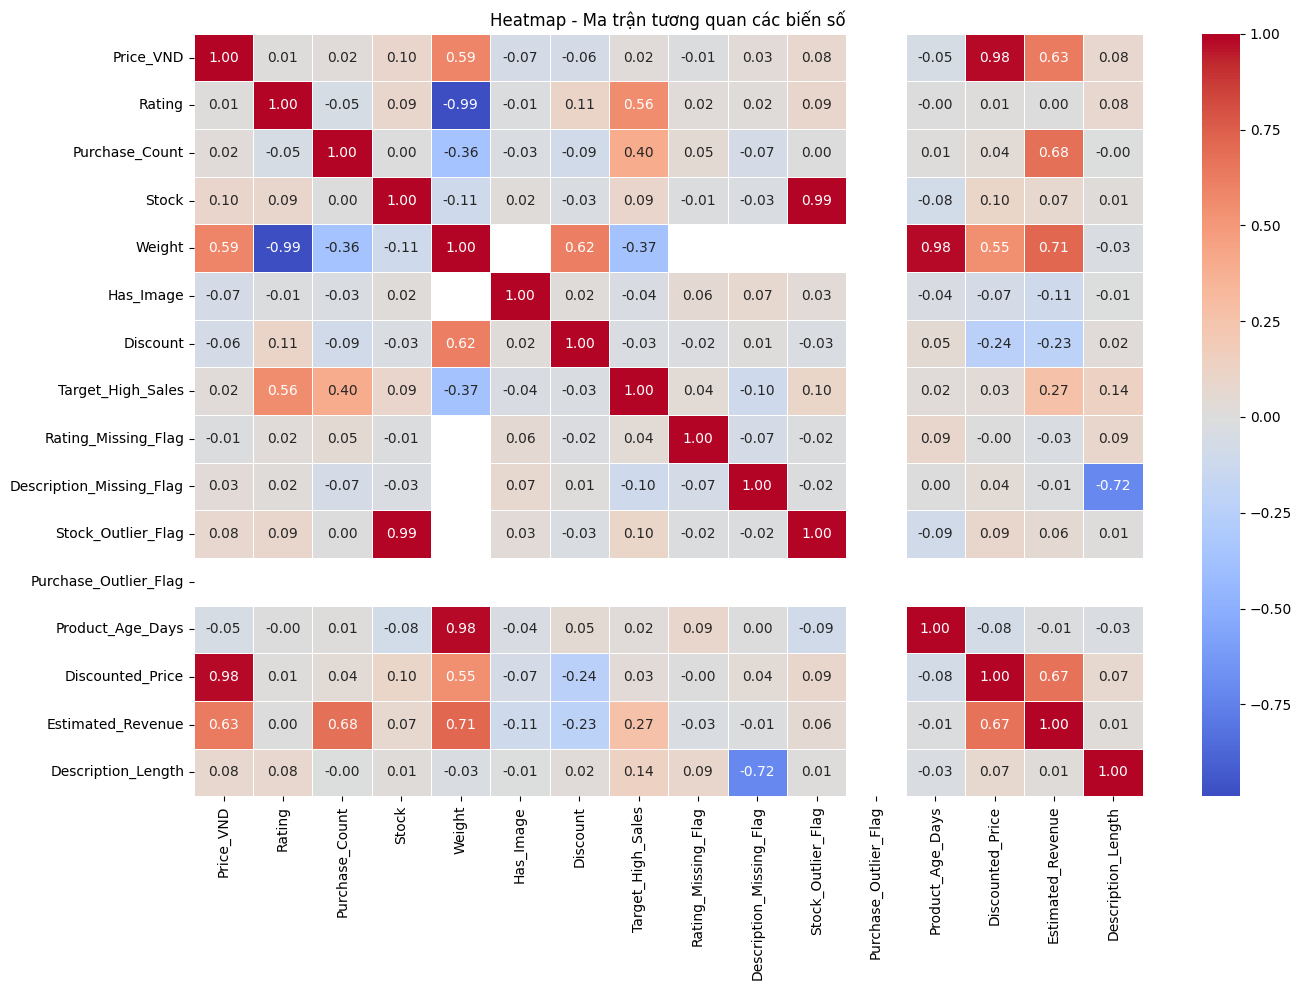


===== CÁC CẶP CÓ |r| LỚN =====


,Biến 1,Biến 2,Correlation,|r|
45,Stock,Stock_Outlier_Flag,0.992,0.992
16,Rating,Weight,-0.990,0.990
11,Price_VND,Discounted_Price,0.979,0.979
52,Weight,Product_Age_Days,0.979,0.979
90,Description_Missing_Flag,Description_Length,-0.716,0.716
54,Weight,Estimated_Revenue,0.714,0.714
37,Purchase_Count,Estimated_Revenue,0.678,0.678
98,Discounted_Price,Estimated_Revenue,0.666,0.666
12,Price_VND,Estimated_Revenue,0.630,0.630
50,Weight,Discount,0.619,0.619



===== CÁC CẶP CÓ |r| >= 0.8 =====


,Biến 1,Biến 2,Correlation,|r|
45,Stock,Stock_Outlier_Flag,0.992,0.992
16,Rating,Weight,-0.990,0.990
11,Price_VND,Discounted_Price,0.979,0.979
52,Weight,Product_Age_Days,0.979,0.979



===== LOẠI PRODUCT_ID =====
Product_ID đã được loại khỏi tập đặc trưng.

===== CHUẨN BỊ SELECTKBEST =====
Số đặc trưng ban đầu: 15
Số dòng dùng cho SelectKBest: 223

===== VARIANCE THRESHOLD =====
Số đặc trưng trước: 15
Số đặc trưng sau VarianceThreshold: 14
Số đặc trưng bị loại: 1

Các đặc trưng bị loại vì phương sai = 0:
- Purchase_Outlier_Flag

===== SELECTKBEST =====
Số đặc trưng trước SelectKBest: 14
Số đặc trưng được chọn: 10

Các đặc trưng được chọn:
- Rating
- Purchase_Count
- Stock
- Weight
- Has_Image
- Rating_Missing_Flag
- Description_Missing_Flag
- Stock_Outlier_Flag
- Estimated_Revenue
- Description_Length

Các đặc trưng bị loại bởi SelectKBest:
- Price_VND
- Discount
- Product_Age_Days
- Discounted_Price

===== ĐIỂM SELECTKBEST =====


,Feature,F_score,p_value
1,Rating,98.6216,0.0000
2,Purchase_Count,41.4037,0.0000
12,Estimated_Revenue,16.7613,0.0001
13,Description_Length,4.2536,0.0403
8,Description_Missing_Flag,2.4394,0.1197
9,Stock_Outlier_Flag,2.1975,0.1397
3,Stock,1.9683,0.1620
7,Rating_Missing_Flag,0.3181,0.5733
4,Weight,0.2951,0.5875
5,Has_Image,0.2867,0.5929



===== TẬP ĐẶC TRƯNG SAU LỰA CHỌN =====
Các cột được sử dụng:
['Rating', 'Purchase_Count', 'Stock', 'Weight', 'Has_Image', 'Rating_Missing_Flag', 'Description_Missing_Flag', 'Stock_Outlier_Flag', 'Estimated_Revenue', 'Description_Length']


,Rating,Purchase_Count,Stock,Weight,Has_Image,Rating_Missing_Flag,Description_Missing_Flag,Stock_Outlier_Flag,Estimated_Revenue,Description_Length
0,3.2,2290.0,140.0,NaN,1,0,0,0,1.431250e+09,34
1,3.9,1405.0,107.0,NaN,1,0,0,0,5.296850e+08,28
2,3.6,1081.0,87.0,NaN,1,0,1,0,8.423692e+08,14
3,4.4,323.0,84.0,NaN,1,0,0,0,2.262292e+08,43
4,3.9,1655.0,190.0,NaN,1,0,0,0,1.662034e+09,34



GIẢI THÍCH TƯƠNG QUAN

Correlation chỉ cho biết mức độ liên hệ tuyến tính giữa
hai biến.

Ví dụ:
- r gần +1: tương quan tuyến tính dương mạnh.
- r gần -1: tương quan tuyến tính âm mạnh.
- r gần 0: ít hoặc không có tương quan tuyến tính.

Tuy nhiên, tương quan cao KHÔNG chứng minh rằng một biến
gây ra biến còn lại.

Có thể tồn tại:
- Biến thứ ba tác động lên cả hai biến.
- Quan hệ ngược chiều.
- Quan hệ chỉ là thống kê/ngẫu nhiên.
- Quan hệ phi tuyến mà Pearson correlation không phản ánh tốt.

Vì vậy không được kết luận quan hệ nhân quả chỉ dựa trên
ma trận tương quan.



In [19]:
# ============================================================
# BÀI 13: TƯƠNG QUAN VÀ CHỌN ĐẶC TRƯNG
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif


print("================================================")
print("BÀI 13 - TƯƠNG QUAN VÀ CHỌN ĐẶC TRƯNG")
print("================================================")


# ============================================================
# 1. Kiểm tra dữ liệu
# ============================================================

print("\n===== THÔNG TIN DỮ LIỆU =====")

print("Số dòng df_clean:", len(df_clean))
print("Số cột df_clean :", len(df_clean.columns))


# ============================================================
# 2. Lấy các biến số
# ============================================================

numeric_columns = df_clean.select_dtypes(
    include=np.number
).columns.tolist()

print("\n===== CÁC BIẾN SỐ =====")

for col in numeric_columns:
    print("-", col)


# ============================================================
# 3. Tạo ma trận tương quan
# ============================================================

numeric_df = df_clean[
    numeric_columns
].copy()

correlation_matrix = numeric_df.corr(
    method="pearson"
)


print("\n===== MA TRẬN TƯƠNG QUAN =====")

display(
    correlation_matrix.round(3)
)


# ============================================================
# 4. Vẽ Heatmap
# ============================================================

plt.figure(
    figsize=(14, 10)
)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title(
    "Heatmap - Ma trận tương quan các biến số"
)

plt.tight_layout()
plt.show()


# ============================================================
# 5. Tìm các cặp có |r| lớn
# ============================================================

print("\n===== CÁC CẶP CÓ |r| LỚN =====")

correlation_pairs = []

columns = correlation_matrix.columns

for i in range(len(columns)):

    for j in range(i + 1, len(columns)):

        col1 = columns[i]
        col2 = columns[j]

        r = correlation_matrix.loc[
            col1,
            col2
        ]

        if not pd.isna(r):

            correlation_pairs.append({
                "Biến 1": col1,
                "Biến 2": col2,
                "Correlation": r,
                "|r|": abs(r)
            })


correlation_pairs_df = pd.DataFrame(
    correlation_pairs
).sort_values(
    "|r|",
    ascending=False
)


# Hiển thị các cặp có |r| >= 0.5
high_correlation_pairs = (
    correlation_pairs_df[
        correlation_pairs_df["|r|"] >= 0.5
    ]
)


if len(high_correlation_pairs) > 0:

    display(
        high_correlation_pairs.round(3)
    )

else:

    print(
        "Không có cặp biến nào có |r| >= 0.5."
    )


# ============================================================
# 6. Tìm các cặp tương quan rất cao |r| >= 0.8
# ============================================================

print("\n===== CÁC CẶP CÓ |r| >= 0.8 =====")

very_high_correlation = (
    correlation_pairs_df[
        correlation_pairs_df["|r|"] >= 0.8
    ]
)


if len(very_high_correlation) > 0:

    display(
        very_high_correlation.round(3)
    )

else:

    print(
        "Không có cặp biến nào có |r| >= 0.8."
    )


# ============================================================
# 7. Loại Product_ID khỏi tập đặc trưng
# ============================================================

print("\n===== LOẠI PRODUCT_ID =====")

if "Product_ID" in df_clean.columns:

    X_base = df_clean.drop(
        columns=["Product_ID"]
    ).copy()

    print(
        "Product_ID đã được loại khỏi tập đặc trưng."
    )

else:

    X_base = df_clean.copy()

    print(
        "Không tìm thấy Product_ID."
    )


# ============================================================
# 8. Chuẩn bị X và y cho SelectKBest
# ============================================================

print("\n===== CHUẨN BỊ SELECTKBEST =====")

if "Target_High_Sales" in df_clean.columns:

    # Chỉ lấy biến số
    feature_candidates = df_clean.select_dtypes(
        include=np.number
    ).columns.tolist()

    # Không dùng target làm feature
    feature_candidates = [
        col
        for col in feature_candidates
        if col != "Target_High_Sales"
        and col != "Product_ID"
    ]

    X = df_clean[
        feature_candidates
    ].copy()

    y = pd.to_numeric(
        df_clean["Target_High_Sales"],
        errors="coerce"
    )

    # Chỉ giữ dòng target hợp lệ
    valid_target = y.notna()

    X = X.loc[
        valid_target
    ]

    y = y.loc[
        valid_target
    ]

    # Điền median cho biến số để SelectKBest chạy được
    X = X.replace(
        [np.inf, -np.inf],
        np.nan
    )

    X = X.fillna(
        X.median()
    )

    print(
        "Số đặc trưng ban đầu:",
        X.shape[1]
    )

    print(
        "Số dòng dùng cho SelectKBest:",
        X.shape[0]
    )


    # ========================================================
    # 9. VarianceThreshold
    # ========================================================

    print("\n===== VARIANCE THRESHOLD =====")

    variance_selector = VarianceThreshold(
        threshold=0.0
    )

    X_variance = variance_selector.fit_transform(
        X
    )

    selected_variance_columns = (
        X.columns[
            variance_selector.get_support()
        ]
        .tolist()
    )

    removed_variance_columns = [
        col
        for col in X.columns
        if col not in selected_variance_columns
    ]

    print(
        "Số đặc trưng trước:",
        X.shape[1]
    )

    print(
        "Số đặc trưng sau VarianceThreshold:",
        len(selected_variance_columns)
    )

    print(
        "Số đặc trưng bị loại:",
        len(removed_variance_columns)
    )

    if len(removed_variance_columns) > 0:

        print(
            "\nCác đặc trưng bị loại vì phương sai = 0:"
        )

        for col in removed_variance_columns:
            print("-", col)

    else:

        print(
            "Không có đặc trưng nào bị loại "
            "bởi VarianceThreshold."
        )


    # ========================================================
    # 10. SelectKBest
    # ========================================================

    print("\n===== SELECTKBEST =====")

    # Chọn tối đa 10 đặc trưng
    k = min(
        10,
        X_variance.shape[1]
    )

    if k > 0:

        select_k_best = SelectKBest(
            score_func=f_classif,
            k=k
        )

        X_selected = select_k_best.fit_transform(
            X_variance,
            y
        )

        variance_feature_names = np.array(
            selected_variance_columns
        )

        selected_kbest_columns = (
            variance_feature_names[
                select_k_best.get_support()
            ]
            .tolist()
        )

        removed_kbest_columns = [
            col
            for col in selected_variance_columns
            if col not in selected_kbest_columns
        ]

        scores = pd.DataFrame({
            "Feature": variance_feature_names,
            "F_score": select_k_best.scores_,
            "p_value": select_k_best.pvalues_
        }).sort_values(
            "F_score",
            ascending=False
        )

        print(
            "Số đặc trưng trước SelectKBest:",
            len(selected_variance_columns)
        )

        print(
            "Số đặc trưng được chọn:",
            len(selected_kbest_columns)
        )

        print("\nCác đặc trưng được chọn:")

        for col in selected_kbest_columns:
            print("-", col)

        print(
            "\nCác đặc trưng bị loại bởi SelectKBest:"
        )

        if len(removed_kbest_columns) > 0:

            for col in removed_kbest_columns:
                print("-", col)

        else:

            print(
                "Không có đặc trưng nào bị loại."
            )

        print(
            "\n===== ĐIỂM SELECTKBEST ====="
        )

        display(
            scores.round(4)
        )


    # ========================================================
    # 11. Tạo dataframe đặc trưng cuối
    # ========================================================

    selected_features = selected_kbest_columns

    df_features = df_clean[
        selected_features
    ].copy()

    print(
        "\n===== TẬP ĐẶC TRƯNG SAU LỰA CHỌN ====="
    )

    print(
        "Các cột được sử dụng:"
    )

    print(
        selected_features
    )

    display(
        df_features.head()
    )


else:

    print(
        "Không tìm thấy Target_High_Sales."
    )

    print(
        "Không thể thực hiện SelectKBest."
    )


# ============================================================
# 12. Giải thích tương quan
# ============================================================

print("""
================================================
GIẢI THÍCH TƯƠNG QUAN
================================================

Correlation chỉ cho biết mức độ liên hệ tuyến tính giữa
hai biến.

Ví dụ:
- r gần +1: tương quan tuyến tính dương mạnh.
- r gần -1: tương quan tuyến tính âm mạnh.
- r gần 0: ít hoặc không có tương quan tuyến tính.

Tuy nhiên, tương quan cao KHÔNG chứng minh rằng một biến
gây ra biến còn lại.

Có thể tồn tại:
- Biến thứ ba tác động lên cả hai biến.
- Quan hệ ngược chiều.
- Quan hệ chỉ là thống kê/ngẫu nhiên.
- Quan hệ phi tuyến mà Pearson correlation không phản ánh tốt.

Vì vậy không được kết luận quan hệ nhân quả chỉ dựa trên
ma trận tương quan.
""")

BÀI 14 — TRỰC QUAN HÓA KẾT QUẢ SAU LÀM SẠCH

BÀI 14 - TRỰC QUAN HÓA SAU LÀM SẠCH


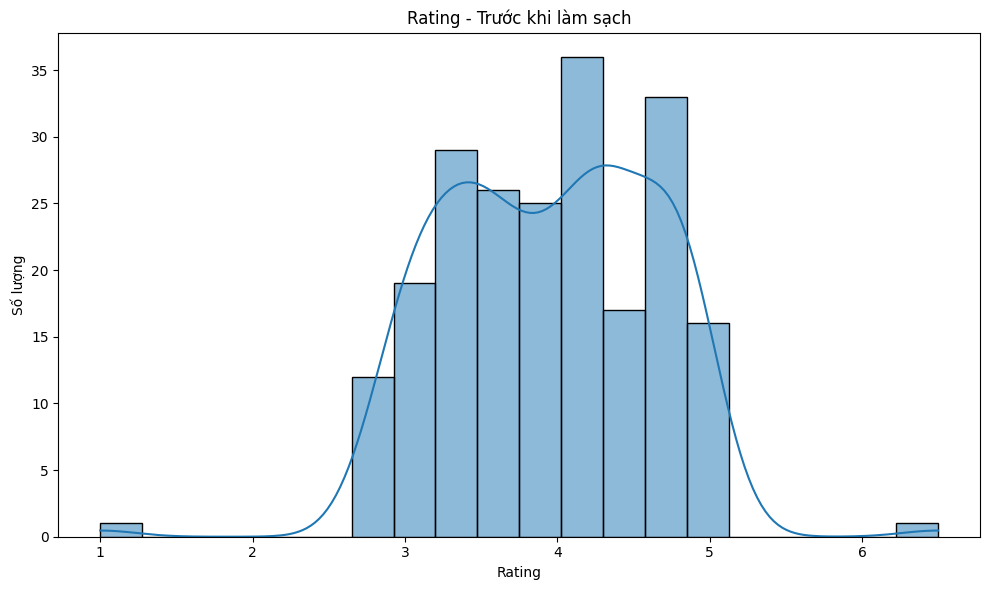

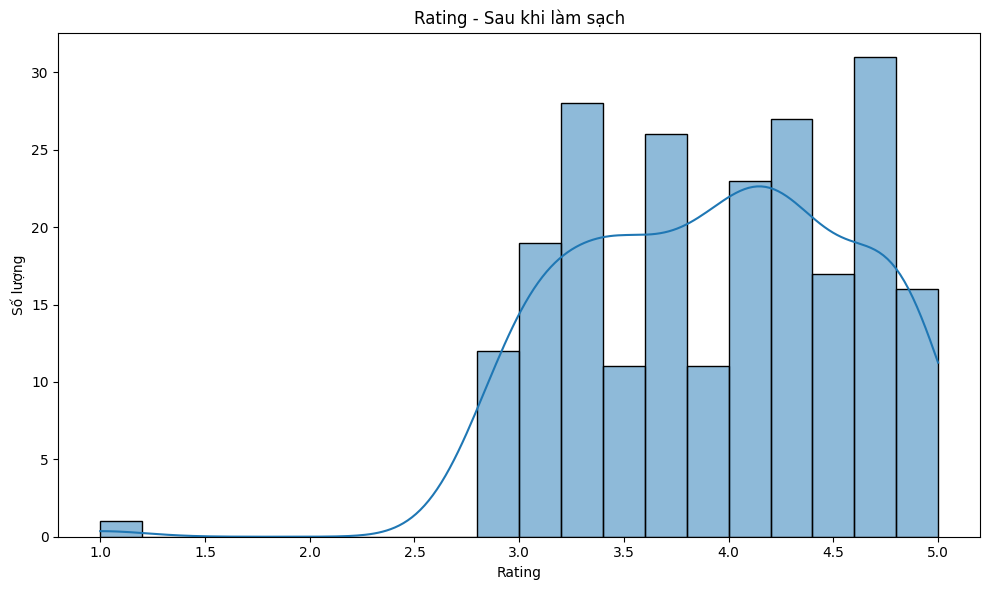

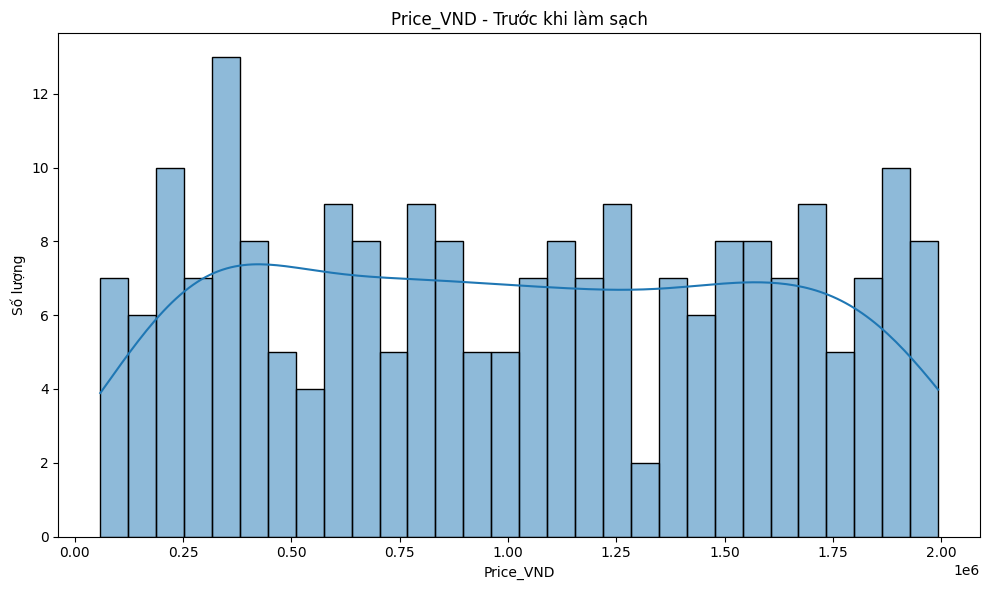

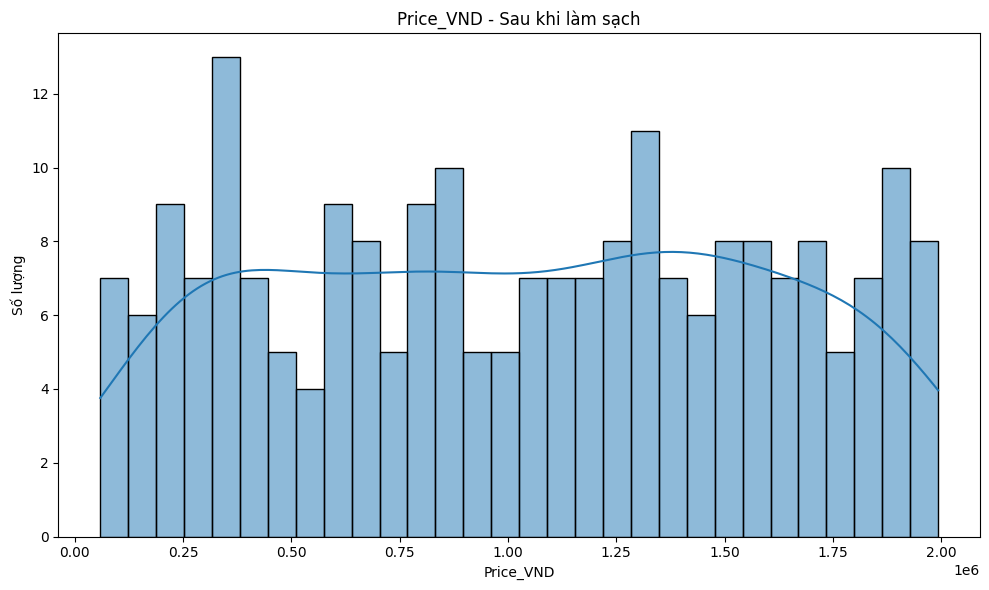

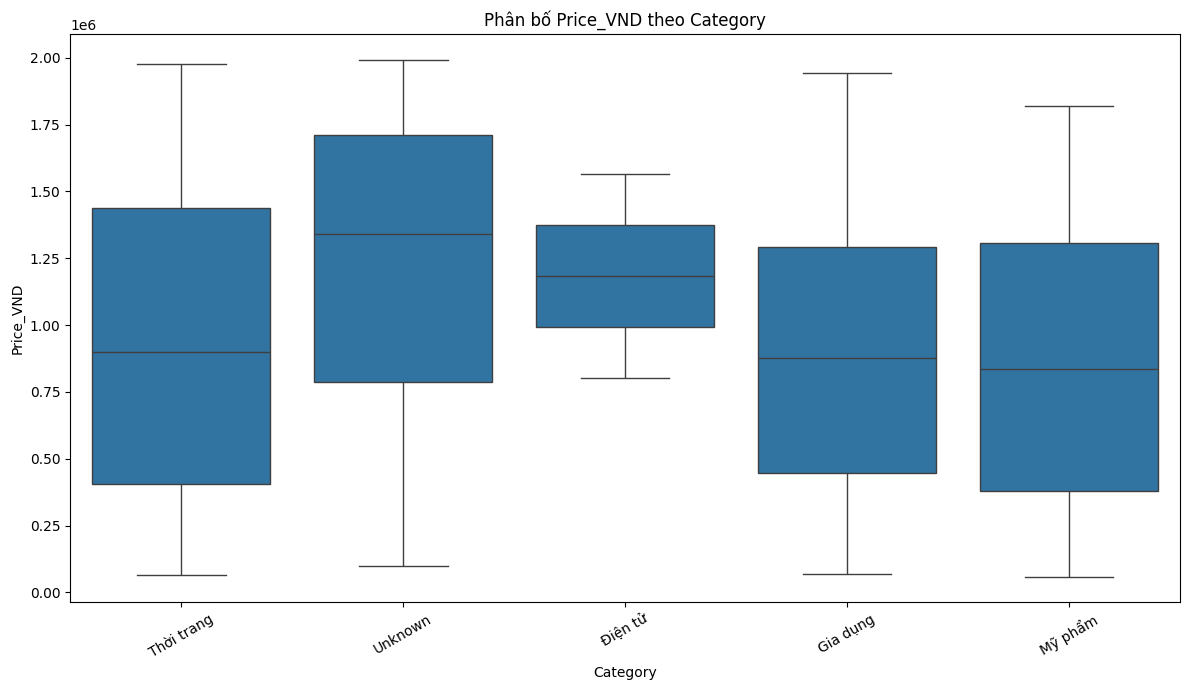


===== SỐ SẢN PHẨM THEO CATEGORY =====


,Số sản phẩm
Category,
Unknown,90
Thời trang,44
Mỹ phẩm,44
Gia dụng,43
Điện tử,2


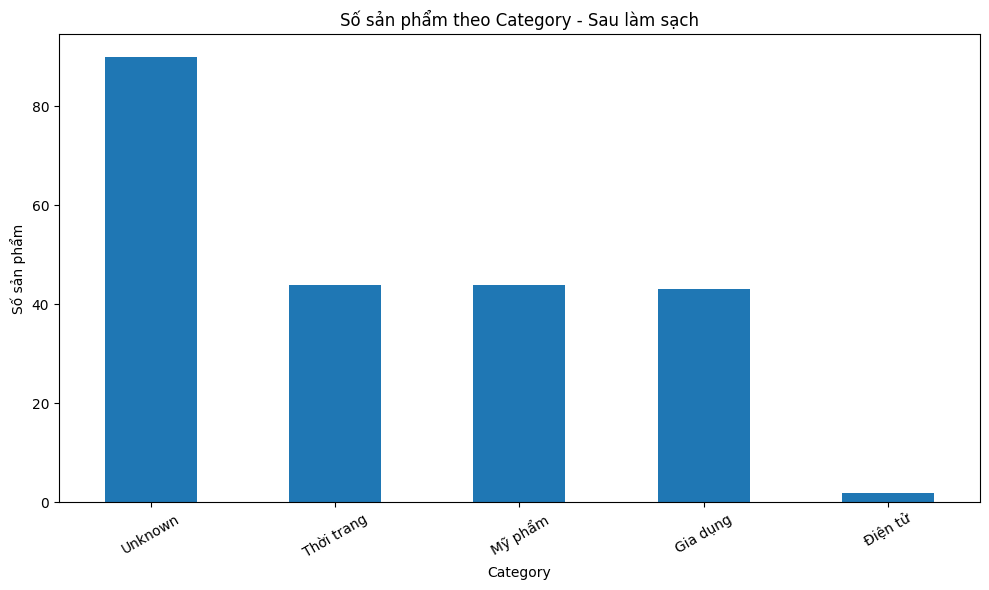


===== DOANH THU ƯỚC TÍNH THEO CATEGORY =====


,Estimated_Revenue
Category,
Unknown,1.195799e+11
Thời trang,4.928565e+10
Mỹ phẩm,4.352321e+10
Gia dụng,4.223897e+10
Điện tử,1.222207e+09


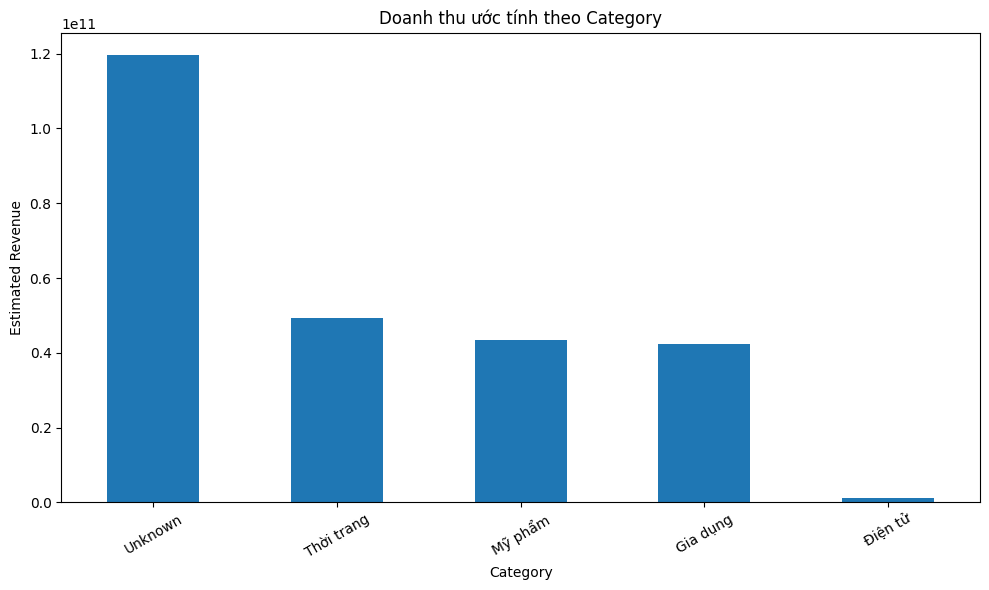


SO SÁNH TRƯỚC VÀ SAU LÀM SẠCH


,Chỉ tiêu,Số lượng trước,Số lượng sau,Median trước,Median sau
0,Rating,215,222,4.0,4.0
1,Price_VND,217,223,1025000.0,1048000.0



===== SKEWNESS TRƯỚC / SAU =====


,Biến,Skewness trước,Skewness sau
0,Rating,-0.168,-0.410
1,Price_VND,0.047,-0.005



NHẬN XÉT SO SÁNH

1. Rating:
   Sau khi làm sạch, các giá trị không hợp lệ ngoài miền
   1–5 đã được xử lý. Phân bố sau làm sạch phản ánh các
   Rating hợp lệ tốt hơn dữ liệu ban đầu.

2. Price_VND:
   Sau khi chuyển đổi kiểu dữ liệu và xử lý giá trị không
   hợp lệ, Price_VND có thể được biểu diễn dưới dạng số
   và dùng cho histogram, thống kê và boxplot.

3. Boxplot theo Category:
   Cho phép so sánh trung vị, khoảng tứ phân vị và các
   giá trị ngoại lệ của giá giữa các nhóm sản phẩm.

4. Số sản phẩm theo Category:
   Cho biết quy mô dữ liệu của từng nhóm sau chuẩn hóa.

5. Estimated_Revenue:
   Cho biết tổng doanh thu ước tính của từng Category,
   được tính từ giá sau giảm và số lượt mua.

Lưu ý:
Biểu đồ trước và sau có thể thay đổi do các giá trị lỗi,
thiếu hoặc không hợp lệ đã được chuyển đổi/xử lý.
Không nên kết luận nguyên nhân kinh doanh chỉ từ biểu đồ.



In [20]:
# ============================================================
# BÀI 14: TRỰC QUAN HÓA KẾT QUẢ SAU LÀM SẠCH
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re


print("================================================")
print("BÀI 14 - TRỰC QUAN HÓA SAU LÀM SẠCH")
print("================================================")


# ============================================================
# 1. Hàm chuyển Rating của dữ liệu RAW
# ============================================================

def convert_raw_rating(value):

    if pd.isna(value):
        return np.nan

    x = str(value).strip()

    match = re.search(
        r"\d+(?:[.,]\d+)?",
        x
    )

    if match is None:
        return np.nan

    try:

        return float(
            match.group().replace(",", ".")
        )

    except:

        return np.nan


# ============================================================
# 2. Hàm chuyển Price_VND của dữ liệu RAW
# ============================================================

def convert_raw_price(value):

    if pd.isna(value):
        return np.nan

    x = str(value).strip().lower()

    # "miễn phí" được giữ là missing để so sánh
    # với quyết định xử lý ở Bài 6/8
    if (
        "miễn phí" in x
        or "mien phi" in x
    ):
        return np.nan

    x = x.replace(
        "vnd", ""
    )

    x = x.replace(
        "vnđ", ""
    )

    x = x.replace(
        "đ", ""
    )

    x = x.replace(
        "₫", ""
    )

    x = x.strip()

    if x == "":
        return np.nan

    # Xử lý số có cả dấu chấm và phẩy
    if "," in x and "." in x:

        if x.rfind(",") > x.rfind("."):

            x = x.replace(
                ".",
                ""
            )

            x = x.replace(
                ",",
                "."
            )

        else:

            x = x.replace(
                ",",
                ""
            )

    elif "," in x:

        x = x.replace(
            ",",
            ""
        )

    elif "." in x:

        parts = x.split(".")

        if (
            all(
                p.isdigit()
                for p in parts
            )
            and len(parts[-1]) == 3
        ):

            x = "".join(parts)

    try:

        number = float(x)

        if number <= 0:
            return np.nan

        return number

    except:

        return np.nan


# ============================================================
# 3. Chuẩn bị dữ liệu RAW để so sánh
# ============================================================

df_raw_compare = df_raw.copy()


if "Rating" in df_raw_compare.columns:

    df_raw_compare[
        "Rating_numeric"
    ] = df_raw_compare[
        "Rating"
    ].apply(
        convert_raw_rating
    )


if "Price_VND" in df_raw_compare.columns:

    df_raw_compare[
        "Price_numeric"
    ] = df_raw_compare[
        "Price_VND"
    ].apply(
        convert_raw_price
    )


# ============================================================
# 4. BIỂU ĐỒ 1 - Rating TRƯỚC XỬ LÝ
# ============================================================

plt.figure(
    figsize=(10, 6)
)

sns.histplot(
    df_raw_compare[
        "Rating_numeric"
    ].dropna(),
    bins=20,
    kde=True
)

plt.title(
    "Rating - Trước khi làm sạch"
)

plt.xlabel(
    "Rating"
)

plt.ylabel(
    "Số lượng"
)

plt.tight_layout()
plt.show()


# ============================================================
# 5. BIỂU ĐỒ 2 - Rating SAU XỬ LÝ
# ============================================================

plt.figure(
    figsize=(10, 6)
)

sns.histplot(
    df_clean[
        "Rating"
    ].dropna(),
    bins=20,
    kde=True
)

plt.title(
    "Rating - Sau khi làm sạch"
)

plt.xlabel(
    "Rating"
)

plt.ylabel(
    "Số lượng"
)

plt.tight_layout()
plt.show()


# ============================================================
# 6. BIỂU ĐỒ 3 - Price TRƯỚC XỬ LÝ
# ============================================================

plt.figure(
    figsize=(10, 6)
)

sns.histplot(
    df_raw_compare[
        "Price_numeric"
    ].dropna(),
    bins=30,
    kde=True
)

plt.title(
    "Price_VND - Trước khi làm sạch"
)

plt.xlabel(
    "Price_VND"
)

plt.ylabel(
    "Số lượng"
)

plt.tight_layout()
plt.show()


# ============================================================
# 7. BIỂU ĐỒ 4 - Price SAU XỬ LÝ
# ============================================================

plt.figure(
    figsize=(10, 6)
)

sns.histplot(
    df_clean[
        "Price_VND"
    ].dropna(),
    bins=30,
    kde=True
)

plt.title(
    "Price_VND - Sau khi làm sạch"
)

plt.xlabel(
    "Price_VND"
)

plt.ylabel(
    "Số lượng"
)

plt.tight_layout()
plt.show()


# ============================================================
# 8. BIỂU ĐỒ 5 - BOXPLOT PRICE THEO CATEGORY
# ============================================================

plt.figure(
    figsize=(12, 7)
)

sns.boxplot(
    data=df_clean,
    x="Category",
    y="Price_VND"
)

plt.title(
    "Phân bố Price_VND theo Category"
)

plt.xlabel(
    "Category"
)

plt.ylabel(
    "Price_VND"
)

plt.xticks(
    rotation=30
)

plt.tight_layout()
plt.show()


# ============================================================
# 9. Tính số sản phẩm theo Category
# ============================================================

category_count = (
    df_clean
    .groupby("Category")
    .size()
    .sort_values(
        ascending=False
    )
)


print("\n===== SỐ SẢN PHẨM THEO CATEGORY =====")

display(
    category_count.to_frame(
        "Số sản phẩm"
    )
)


# ============================================================
# 10. BIỂU ĐỒ 6 - SỐ SẢN PHẨM THEO CATEGORY
# ============================================================

plt.figure(
    figsize=(10, 6)
)

category_count.plot(
    kind="bar"
)

plt.title(
    "Số sản phẩm theo Category - Sau làm sạch"
)

plt.xlabel(
    "Category"
)

plt.ylabel(
    "Số sản phẩm"
)

plt.xticks(
    rotation=30
)

plt.tight_layout()
plt.show()


# ============================================================
# 11. Doanh thu ước tính theo Category
# ============================================================

category_revenue = (
    df_clean
    .groupby("Category")[
        "Estimated_Revenue"
    ]
    .sum()
    .sort_values(
        ascending=False
    )
)


print(
    "\n===== DOANH THU ƯỚC TÍNH THEO CATEGORY ====="
)

display(
    category_revenue.to_frame(
        "Estimated_Revenue"
    )
)


# ============================================================
# 12. BIỂU ĐỒ 7 - DOANH THU ƯỚC TÍNH THEO CATEGORY
# ============================================================

plt.figure(
    figsize=(10, 6)
)

category_revenue.plot(
    kind="bar"
)

plt.title(
    "Doanh thu ước tính theo Category"
)

plt.xlabel(
    "Category"
)

plt.ylabel(
    "Estimated Revenue"
)

plt.xticks(
    rotation=30
)

plt.tight_layout()
plt.show()


# ============================================================
# 13. So sánh thống kê trước/sau
# ============================================================

print(
    "\n================================================"
)

print(
    "SO SÁNH TRƯỚC VÀ SAU LÀM SẠCH"
)

print(
    "================================================"
)


comparison_rating_price = pd.DataFrame({

    "Chỉ tiêu": [
        "Rating",
        "Price_VND"
    ],

    "Số lượng trước": [
        df_raw_compare[
            "Rating_numeric"
        ].notna().sum(),

        df_raw_compare[
            "Price_numeric"
        ].notna().sum()
    ],

    "Số lượng sau": [
        df_clean[
            "Rating"
        ].notna().sum(),

        df_clean[
            "Price_VND"
        ].notna().sum()
    ],

    "Median trước": [
        df_raw_compare[
            "Rating_numeric"
        ].median(),

        df_raw_compare[
            "Price_numeric"
        ].median()
    ],

    "Median sau": [
        df_clean[
            "Rating"
        ].median(),

        df_clean[
            "Price_VND"
        ].median()
    ]
})


display(
    comparison_rating_price.round(2)
)


# ============================================================
# 14. Tính skewness trước/sau
# ============================================================

print(
    "\n===== SKEWNESS TRƯỚC / SAU ====="
)

skew_comparison = pd.DataFrame({

    "Biến": [
        "Rating",
        "Price_VND"
    ],

    "Skewness trước": [
        df_raw_compare[
            "Rating_numeric"
        ].skew(),

        df_raw_compare[
            "Price_numeric"
        ].skew()
    ],

    "Skewness sau": [
        df_clean[
            "Rating"
        ].skew(),

        df_clean[
            "Price_VND"
        ].skew()
    ]
})


display(
    skew_comparison.round(3)
)


# ============================================================
# 15. Nhận xét tự động
# ============================================================

print("""
================================================
NHẬN XÉT SO SÁNH
================================================

1. Rating:
   Sau khi làm sạch, các giá trị không hợp lệ ngoài miền
   1–5 đã được xử lý. Phân bố sau làm sạch phản ánh các
   Rating hợp lệ tốt hơn dữ liệu ban đầu.

2. Price_VND:
   Sau khi chuyển đổi kiểu dữ liệu và xử lý giá trị không
   hợp lệ, Price_VND có thể được biểu diễn dưới dạng số
   và dùng cho histogram, thống kê và boxplot.

3. Boxplot theo Category:
   Cho phép so sánh trung vị, khoảng tứ phân vị và các
   giá trị ngoại lệ của giá giữa các nhóm sản phẩm.

4. Số sản phẩm theo Category:
   Cho biết quy mô dữ liệu của từng nhóm sau chuẩn hóa.

5. Estimated_Revenue:
   Cho biết tổng doanh thu ước tính của từng Category,
   được tính từ giá sau giảm và số lượt mua.

Lưu ý:
Biểu đồ trước và sau có thể thay đổi do các giá trị lỗi,
thiếu hoặc không hợp lệ đã được chuyển đổi/xử lý.
Không nên kết luận nguyên nhân kinh doanh chỉ từ biểu đồ.
""")

BÀI 15 — KIỂM TRA CUỐI VÀ XUẤT DỮ LIỆU

In [21]:
# ============================================================
# BÀI 15: KIỂM TRA CUỐI VÀ XUẤT DỮ LIỆU
# ============================================================

import pandas as pd
import numpy as np
import os


print("================================================")
print("BÀI 15 - KIỂM TRA CUỐI VÀ XUẤT DỮ LIỆU")
print("================================================")


# ============================================================
# 1. Kiểm tra kích thước dữ liệu
# ============================================================

print("\n===== KÍCH THƯỚC DỮ LIỆU =====")

print(
    "df_raw    :",
    df_raw.shape
)

print(
    "df_clean  :",
    df_clean.shape
)


# ============================================================
# 2. Kiểm tra dòng trùng hoàn toàn
# ============================================================

print("\n===== KIỂM TRA TRÙNG HOÀN TOÀN =====")

duplicate_count = (
    df_clean
    .duplicated()
    .sum()
)

print(
    "Số dòng trùng hoàn toàn:",
    duplicate_count
)

if duplicate_count == 0:

    print(
        "✓ Không còn dòng trùng hoàn toàn."
    )

else:

    print(
        "⚠ Vẫn còn dòng trùng hoàn toàn."
    )


# ============================================================
# 3. Kiểm tra Product_ID trùng
# ============================================================

print("\n===== KIỂM TRA PRODUCT_ID =====")

if "Product_ID" in df_clean.columns:

    duplicate_product_id = (
        df_clean[
            "Product_ID"
        ]
        .duplicated(keep=False)
        .sum()
    )

    print(
        "Số dòng có Product_ID trùng:",
        duplicate_product_id
    )

    if duplicate_product_id > 0:

        print(
            "Lưu ý: Product_ID trùng nhưng nội dung khác "
            "được giữ lại và đánh dấu."
        )

        if "Duplicate_ID_Flag" in df_clean.columns:

            print(
                "Số dòng Duplicate_ID_Flag = True:",
                df_clean[
                    "Duplicate_ID_Flag"
                ].sum()
            )


# ============================================================
# 4. Kiểm tra dtype các cột quan trọng
# ============================================================

print("\n===== KIỂM TRA DTYPE =====")

important_numeric_columns = [
    "Price_VND",
    "Rating",
    "Purchase_Count",
    "Weight",
    "Discount",
    "Stock",
    "Has_Image",
    "Product_Age_Days",
    "Discounted_Price",
    "Estimated_Revenue",
    "Description_Length"
]


dtype_check = []

for col in important_numeric_columns:

    if col in df_clean.columns:

        dtype_check.append({

            "Cột": col,

            "dtype": str(
                df_clean[col].dtype
            ),

            "Là số?": pd.api.types.is_numeric_dtype(
                df_clean[col]
            )
        })


dtype_table = pd.DataFrame(
    dtype_check
)

display(
    dtype_table
)


# ============================================================
# 5. Kiểm tra Created_Date
# ============================================================

print("\n===== KIỂM TRA CREATED_DATE =====")

if "Created_Date" in df_clean.columns:

    is_datetime = (
        pd.api.types.is_datetime64_any_dtype(
            df_clean["Created_Date"]
        )
    )

    print(
        "dtype:",
        df_clean[
            "Created_Date"
        ].dtype
    )

    print(
        "Có phải datetime:",
        is_datetime
    )


# ============================================================
# 6. Kiểm tra miền Rating
# ============================================================

print("\n===== KIỂM TRA RATING =====")

if "Rating" in df_clean.columns:

    rating_invalid = (
        df_clean["Rating"].notna()
        &
        ~df_clean["Rating"].between(
            1,
            5
        )
    )

    print(
        "Rating ngoài [1,5]:",
        rating_invalid.sum()
    )


# ============================================================
# 7. Kiểm tra Price_VND
# ============================================================

print("\n===== KIỂM TRA PRICE_VND =====")

if "Price_VND" in df_clean.columns:

    price_invalid = (
        df_clean["Price_VND"].notna()
        &
        (
            df_clean["Price_VND"] <= 0
        )
    )

    print(
        "Price_VND <= 0:",
        price_invalid.sum()
    )


# ============================================================
# 8. Kiểm tra Stock
# ============================================================

print("\n===== KIỂM TRA STOCK =====")

if "Stock" in df_clean.columns:

    stock_invalid = (
        df_clean["Stock"].notna()
        &
        (
            df_clean["Stock"] < 0
        )
    )

    print(
        "Stock âm:",
        stock_invalid.sum()
    )


# ============================================================
# 9. Kiểm tra Discount
# ============================================================

print("\n===== KIỂM TRA DISCOUNT =====")

if "Discount" in df_clean.columns:

    discount_invalid = (
        df_clean["Discount"].notna()
        &
        ~df_clean["Discount"].between(
            0,
            1
        )
    )

    print(
        "Discount ngoài [0,1]:",
        discount_invalid.sum()
    )


# ============================================================
# 10. Kiểm tra Purchase_Count
# ============================================================

print("\n===== KIỂM TRA PURCHASE_COUNT =====")

if "Purchase_Count" in df_clean.columns:

    purchase_invalid = (
        df_clean["Purchase_Count"].notna()
        &
        (
            df_clean["Purchase_Count"] < 0
        )
    )

    print(
        "Purchase_Count âm:",
        purchase_invalid.sum()
    )


# ============================================================
# 11. Missing report cuối
# ============================================================

print("\n===== MISSING REPORT CUỐI =====")

final_missing = pd.DataFrame({

    "Số lượng thiếu":
        df_clean.isna().sum(),

    "Tỷ lệ thiếu (%)":
        df_clean.isna().mean() * 100

})

final_missing = final_missing.sort_values(
    "Tỷ lệ thiếu (%)",
    ascending=False
)

display(
    final_missing.round(2)
)


# ============================================================
# 12. So sánh số dòng trước và sau
# ============================================================

print("\n===== SO SÁNH SỐ DÒNG =====")

row_comparison = pd.DataFrame({

    "Trước xử lý": [
        len(df_raw)
    ],

    "Sau xử lý": [
        len(df_clean)
    ],

    "Số dòng giảm": [
        len(df_raw) - len(df_clean)
    ]
})

display(
    row_comparison
)


# ============================================================
# 13. So sánh số cột
# ============================================================

print("\n===== SO SÁNH SỐ CỘT =====")

column_comparison = pd.DataFrame({

    "Trước xử lý": [
        len(df_raw.columns)
    ],

    "Sau xử lý": [
        len(df_clean.columns)
    ],

    "Số cột thay đổi": [
        len(df_clean.columns)
        - len(df_raw.columns)
    ]
})

display(
    column_comparison
)


# ============================================================
# 14. Tạo bảng AUDIT cuối
# ============================================================

print("\n===== BẢNG AUDIT CUỐI =====")

audit_final = pd.DataFrame({

    "Chỉ tiêu": [

        "Số dòng",

        "Số cột",

        "Dòng trùng hoàn toàn",

        "Product_ID trùng",

        "Rating ngoài [1,5]",

        "Price_VND <= 0",

        "Stock âm",

        "Discount ngoài [0,1]",

        "Purchase_Count âm",

        "Số ô thiếu"

    ],

    "Kết quả": [

        len(df_clean),

        len(df_clean.columns),

        df_clean.duplicated().sum(),

        (
            df_clean["Product_ID"]
            .duplicated(keep=False)
            .sum()
            if "Product_ID" in df_clean.columns
            else "Không có cột"
        ),

        (
            (
                df_clean["Rating"].notna()
                &
                ~df_clean["Rating"].between(1,5)
            ).sum()
            if "Rating" in df_clean.columns
            else "Không có cột"
        ),

        (
            (
                df_clean["Price_VND"].notna()
                &
                (df_clean["Price_VND"] <= 0)
            ).sum()
            if "Price_VND" in df_clean.columns
            else "Không có cột"
        ),

        (
            (
                df_clean["Stock"].notna()
                &
                (df_clean["Stock"] < 0)
            ).sum()
            if "Stock" in df_clean.columns
            else "Không có cột"
        ),

        (
            (
                df_clean["Discount"].notna()
                &
                ~df_clean["Discount"].between(0,1)
            ).sum()
            if "Discount" in df_clean.columns
            else "Không có cột"
        ),

        (
            (
                df_clean["Purchase_Count"].notna()
                &
                (df_clean["Purchase_Count"] < 0)
            ).sum()
            if "Purchase_Count" in df_clean.columns
            else "Không có cột"
        ),

        df_clean.isna().sum().sum()
    ]
})

display(
    audit_final
)


# ============================================================
# 15. Kiểm tra điều kiện cuối
# ============================================================

print("\n================================================")
print("KIỂM TRA CÁC ĐIỀU KIỆN CUỐI")
print("================================================")


check_duplicate = (
    df_clean.duplicated().sum() == 0
)

check_datetime = (
    "Created_Date" in df_clean.columns
    and
    pd.api.types.is_datetime64_any_dtype(
        df_clean["Created_Date"]
    )
)

check_rating = (
    "Rating" not in df_clean.columns
    or
    (
        (
            df_clean["Rating"].notna()
            &
            ~df_clean["Rating"].between(1,5)
        ).sum()
        == 0
    )
)

check_price = (
    "Price_VND" not in df_clean.columns
    or
    (
        (
            df_clean["Price_VND"].notna()
            &
            (df_clean["Price_VND"] <= 0)
        ).sum()
        == 0
    )
)

check_stock = (
    "Stock" not in df_clean.columns
    or
    (
        (
            df_clean["Stock"].notna()
            &
            (df_clean["Stock"] < 0)
        ).sum()
        == 0
    )
)

check_discount = (
    "Discount" not in df_clean.columns
    or
    (
        (
            df_clean["Discount"].notna()
            &
            ~df_clean["Discount"].between(0,1)
        ).sum()
        == 0
    )
)


checks = pd.DataFrame({

    "Điều kiện": [

        "Không còn dòng trùng hoàn toàn",

        "Created_Date là datetime",

        "Rating thuộc [1,5]",

        "Price_VND > 0",

        "Stock >= 0",

        "Discount thuộc [0,1]"

    ],

    "Đạt": [

        check_duplicate,

        check_datetime,

        check_rating,

        check_price,

        check_stock,

        check_discount

    ]

})

display(
    checks
)


# ============================================================
# 16. Xuất CSV
# ============================================================

csv_path = "/content/Du_lieu_sach.csv"

df_clean.to_csv(
    csv_path,
    index=False,
    encoding="utf-8-sig"
)

print(
    "\n✓ Đã xuất CSV:",
    csv_path
)


# ============================================================
# 17. Xuất XLSX
# ============================================================

xlsx_path = "/content/Du_lieu_sach.xlsx"

df_clean.to_excel(
    xlsx_path,
    index=False
)

print(
    "✓ Đã xuất XLSX:",
    xlsx_path
)


# ============================================================
# 18. Hiển thị link tải
# ============================================================

from IPython.display import FileLink, display

print("\n===== FILE KẾT QUẢ =====")

display(
    FileLink(
        csv_path
    )
)

display(
    FileLink(
        xlsx_path
    )
)


# ============================================================
# 19. KẾT LUẬN BÀI 15
# ============================================================

print("""
================================================
KẾT LUẬN BÀI 15
================================================

Đã kiểm tra:

✓ Dòng trùng hoàn toàn
✓ Product_ID trùng
✓ Kiểu dữ liệu
✓ Created_Date
✓ Rating
✓ Price_VND
✓ Stock
✓ Discount
✓ Purchase_Count
✓ Missing
✓ Số dòng trước/sau
✓ Số cột trước/sau

Đã xuất dữ liệu sạch thành:

1. Du_lieu_sach.csv
2. Du_lieu_sach.xlsx

Lưu ý:
Product_ID trùng nhưng nội dung khác không được tự động
xóa vì không có Updated_Time để xác định bản ghi mới/cũ.

Các Stock outlier cũng không bị tự động xóa nếu chưa có
căn cứ chứng minh đó là lỗi.
""")

BÀI 15 - KIỂM TRA CUỐI VÀ XUẤT DỮ LIỆU

===== KÍCH THƯỚC DỮ LIỆU =====
df_raw    : (228, 14)
df_clean  : (223, 23)

===== KIỂM TRA TRÙNG HOÀN TOÀN =====
Số dòng trùng hoàn toàn: 0
✓ Không còn dòng trùng hoàn toàn.

===== KIỂM TRA PRODUCT_ID =====
Số dòng có Product_ID trùng: 6
Lưu ý: Product_ID trùng nhưng nội dung khác được giữ lại và đánh dấu.
Số dòng Duplicate_ID_Flag = True: 6

===== KIỂM TRA DTYPE =====


,Cột,dtype,Là số?
0,Price_VND,float64,True
1,Rating,float64,True
2,Purchase_Count,float64,True
3,Weight,float64,True
4,Discount,float64,True
5,Stock,float64,True
6,Has_Image,Int64,True
7,Product_Age_Days,float64,True
8,Discounted_Price,float64,True
9,Estimated_Revenue,float64,True



===== KIỂM TRA CREATED_DATE =====
dtype: datetime64[ns]
Có phải datetime: True

===== KIỂM TRA RATING =====
Rating ngoài [1,5]: 0

===== KIỂM TRA PRICE_VND =====
Price_VND <= 0: 0

===== KIỂM TRA STOCK =====
Stock âm: 0

===== KIỂM TRA DISCOUNT =====
Discount ngoài [0,1]: 0

===== KIỂM TRA PURCHASE_COUNT =====
Purchase_Count âm: 0

===== MISSING REPORT CUỐI =====


,Số lượng thiếu,Tỷ lệ thiếu (%)
Weight,220,98.65
Created_Date,10,4.48
Product_Age_Days,10,4.48
Discount,2,0.90
Discounted_Price,2,0.90
Estimated_Revenue,2,0.90
Rating,1,0.45
Stock,1,0.45
Purchase_Count,0,0.00
Product_Name,0,0.00



===== SO SÁNH SỐ DÒNG =====


...

,Điều kiện,Đạt
0,Không còn dòng trùng hoàn toàn,True
1,Created_Date là datetime,True
2,"Rating thuộc [1,5]",True
3,Price_VND > 0,True
4,Stock >= 0,True
5,"Discount thuộc [0,1]",True



✓ Đã xuất CSV: /content/Du_lieu_sach.csv
✓ Đã xuất XLSX: /content/Du_lieu_sach.xlsx

===== FILE KẾT QUẢ =====


/content/Du_lieu_sach.csv

/content/Du_lieu_sach.xlsx


KẾT LUẬN BÀI 15

Đã kiểm tra:

✓ Dòng trùng hoàn toàn
✓ Product_ID trùng
✓ Kiểu dữ liệu
✓ Created_Date
✓ Rating
✓ Price_VND
✓ Stock
✓ Discount
✓ Purchase_Count
✓ Missing
✓ Số dòng trước/sau
✓ Số cột trước/sau

Đã xuất dữ liệu sạch thành:

1. Du_lieu_sach.csv
2. Du_lieu_sach.xlsx

Lưu ý:
Product_ID trùng nhưng nội dung khác không được tự động
xóa vì không có Updated_Time để xác định bản ghi mới/cũ.

Các Stock outlier cũng không bị tự động xóa nếu chưa có
căn cứ chứng minh đó là lỗi.



Câu 67. Dữ liệu thiếu ở Price_VND nên điền median toàn bộ hay median theo Category?

Theo mình, nên ưu tiên median theo Category nếu các nhóm sản phẩm có mức giá khác nhau đáng kể.

Ví dụ, nếu giá của nhóm Điện tử thường cao hơn nhóm Mỹ phẩm thì dùng median toàn bộ sẽ làm giá trị thiếu của cả hai nhóm bị kéo về một mức chung. Median theo Category giữ được sự khác biệt về mức giá giữa các nhóm.

Median toàn bộ đơn giản hơn và phù hợp khi:

Các nhóm có phân phối giá tương đối giống nhau.
Một số nhóm có quá ít dữ liệu nên không tính được median riêng.
Mục tiêu chỉ cần một giá trị thay thế đơn giản.

Kết luận: với dữ liệu sản phẩm có nhiều Category, median theo Category thường hợp lý hơn; nếu Category không đủ dữ liệu thì có thể dùng median toàn bộ làm phương án dự phòng.

Điều này phù hợp với yêu cầu đề bài cho phép cân nhắc median theo Category thay vì median toàn bộ.

Câu 68. Chuỗi "miễn phí" trong Price_VND nên chuyển thành 0 hay NaN?

Điều này phụ thuộc vào ý nghĩa của dữ liệu và mục tiêu phân tích.

Nếu "miễn phí" thực sự có nghĩa là sản phẩm có giá bán bằng 0 thì có thể chuyển thành:

0 VND

Cách này phù hợp khi phân tích cần giữ các sản phẩm miễn phí như một nhóm giá hợp lệ.

Ngược lại, nếu "miễn phí" chỉ có nghĩa là không có thông tin giá, thì nên chuyển thành:

NaN

để tránh giả định rằng sản phẩm có giá bằng 0.

Trong bài này, nên chọn NaN nếu chưa có căn cứ chắc chắn rằng "miễn phí" mang nghĩa giá bằng 0, sau đó xử lý missing theo quy tắc của Price_VND.

Đề cũng yêu cầu phải tự quyết định cách xử lý "miễn phí" và giải thích quyết định đó.

Câu 69. Vì sao không nên xóa tất cả điểm nằm ngoài ngưỡng IQR?

Vì một điểm nằm ngoài IQR chưa chắc là dữ liệu sai.

Ví dụ:

Stock = 9999

có thể là lỗi nhập dữ liệu, nhưng cũng có thể là một sản phẩm thực sự có lượng tồn kho rất lớn.

Nếu xóa toàn bộ outlier bằng IQR, ta có thể vô tình loại bỏ những quan sát hợp lệ.

Do đó cần phân biệt:

Outlier thống kê
        ≠
Dữ liệu sai

Cách phù hợp là:

Dùng IQR để phát hiện/gắn cờ.
Kiểm tra ngữ cảnh.
Chỉ sửa hoặc xóa nếu có căn cứ.
Với trường hợp chưa chắc chắn, giữ dữ liệu và tạo cờ như Stock_Outlier_Flag.

Điều này đúng với yêu cầu của đề đối với Stock=9999.

Câu 70. Product_ID trùng nhưng nội dung khác cần xử lý thế nào khi không có thời điểm cập nhật?

Không nên sử dụng:

drop_duplicates("Product_ID")

một cách tùy tiện vì không biết bản ghi nào là đúng hoặc mới hơn.

Có thể xử lý như sau:

Product_ID trùng
       ↓
Kiểm tra nội dung
       ↓
Nếu giống hoàn toàn → loại bản sao
       ↓
Nếu khác nhau → giữ lại + gắn cờ

Ví dụ:

Duplicate_ID_Flag = True

Sau đó cần thêm thông tin như:

Updated_Time
version/mã phiên bản
trạng thái bản ghi
nguồn dữ liệu

để xác định bản ghi nào nên được giữ.

Đây cũng chính là hướng dẫn của đề: vì dữ liệu không có Updated_Time, cách an toàn là loại trùng hoàn toàn và tạo Duplicate_ID_Flag cho mã còn xung đột.

Câu 71. StandardScaler và RobustScaler khác nhau ra sao khi Stock có giá trị 9999?
StandardScaler

StandardScaler sử dụng:

mean
standard deviation

nên khá nhạy với các giá trị cực lớn.

Nếu Stock có:

9999

thì mean và standard deviation có thể bị ảnh hưởng.

RobustScaler

RobustScaler dựa trên:

median
IQR

nên ít bị ảnh hưởng bởi outlier hơn.

Vì vậy, nếu Stock có những giá trị cực lớn như 9999, RobustScaler thường ít bị outlier chi phối hơn StandardScaler.

Tuy nhiên, điều đó không có nghĩa 9999 phải bị xóa. Cần xác định trước xem nó là lỗi hay một giá trị hợp lệ.

Câu 72. Có nên mã hóa Category bằng 1, 2, 3, 4, 5 không? Vì sao?

Không nên dùng cách này cho Category nếu các nhóm không có thứ tự tự nhiên.

Ví dụ:

Điện tử       → 1
Thời trang    → 2
Gia dụng      → 3
Mỹ phẩm       → 4
Thể thao      → 5

Mô hình có thể hiểu nhầm:

5 > 4 > 3 > 2 > 1

tức là có thứ tự giữa các Category.

Trong thực tế:

Điện tử
Thời trang
Gia dụng
Mỹ phẩm
Thể thao

không có quan hệ thứ tự như vậy.

Do đó nên dùng One-Hot Encoding, ví dụ:

Category_Điện_tử
Category_Thời_trang
Category_Gia_dụng
Category_Mỹ_phẩm
Category_Thể_thao

mỗi cột nhận 0/1.

Đề cũng yêu cầu không dùng LabelEncoder cho thành phố vì sẽ tạo ra thứ tự giả.

Câu 73. Nếu xây dựng mô hình, tại sao phải chia train/test trước khi fit imputer và scaler?

Để tránh data leakage — rò rỉ dữ liệu.

Ví dụ nếu ta làm:

Toàn bộ dữ liệu
      ↓
Fit median
      ↓
Fit scaler
      ↓
Chia train/test

thì thông tin từ tập test đã được sử dụng để tính median, mean, standard deviation hoặc các tham số biến đổi.

Khi đó test set không còn hoàn toàn "chưa từng được nhìn thấy".

Cách đúng:

Dữ liệu
   ↓
Chia Train / Test
   ↓
Train
   ├── Fit Imputer
   └── Fit Scaler
          ↓
      Transform Train
          ↓
      Transform Test

Tức là:

Chỉ fit imputer/scaler trên train, sau đó dùng chúng để transform test.

Đây là nguyên tắc chống rò rỉ được ghi rõ trong yêu cầu của Tiết 3.

Câu 74. Bộ dữ liệu sạch có phải là bộ dữ liệu không còn giá trị thiếu trong mọi trường hợp không?

Không.

"Dữ liệu sạch" không nhất thiết có nghĩa:

Missing = 0 ở mọi cột

Một số giá trị thiếu có thể không thể xác định chính xác.

Ví dụ:

Created_Date = NaT

Nếu không biết ngày tạo sản phẩm thì không nên tự bịa:

Created_Date = 01/01/2025

chỉ để loại missing.

Trong trường hợp này, giữ NaT có thể là quyết định đúng nếu chưa có nguồn dữ liệu đáng tin cậy để bổ sung.

Tương tự, với Price_VND, việc điền median cũng là một quyết định xử lý dữ liệu, không phải khôi phục chính xác giá thật.

Vì vậy:

Dữ liệu sạch là dữ liệu đã được kiểm tra, xử lý các vấn đề theo quy tắc có lý do và có thể giải thích được; không nhất thiết mọi ô thiếu đều phải bị xóa hoặc điền giá trị.

Đề cũng cho phép Created_Date giữ NaT hoặc loại dòng nếu tỷ lệ rất nhỏ, nhưng không được bịa ngày ngẫu nhiên.